In [49]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils


import copy as _copy, time as _time
import arviz as az
import jax as _jax
import jax.numpy as _jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from getdist import MCSamples
from getdist import plots as gd_plots
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

In [50]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          
DEVELOP = HERE.parents[2]        

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

halo_params_dict['lowpass_Pmm1h_lowk'] = True
halo_params_dict['kthresh_lowpass_Pmm1h_lowk'] = 0.01  # k in h/Mpc below which 1h is suppressed                          
analysis_dict['is_cmb_lensing'] = True          

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=1000.0, dl_log=0.1025851)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 5
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 5
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'mcmc_plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


nell = 24, ell range [84.3, 892.6]
nbar_lens_bins [gal/arcmin²]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots


In [51]:

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


/tmp/ipykernel_273299/3401311558.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/dl_comparison.png


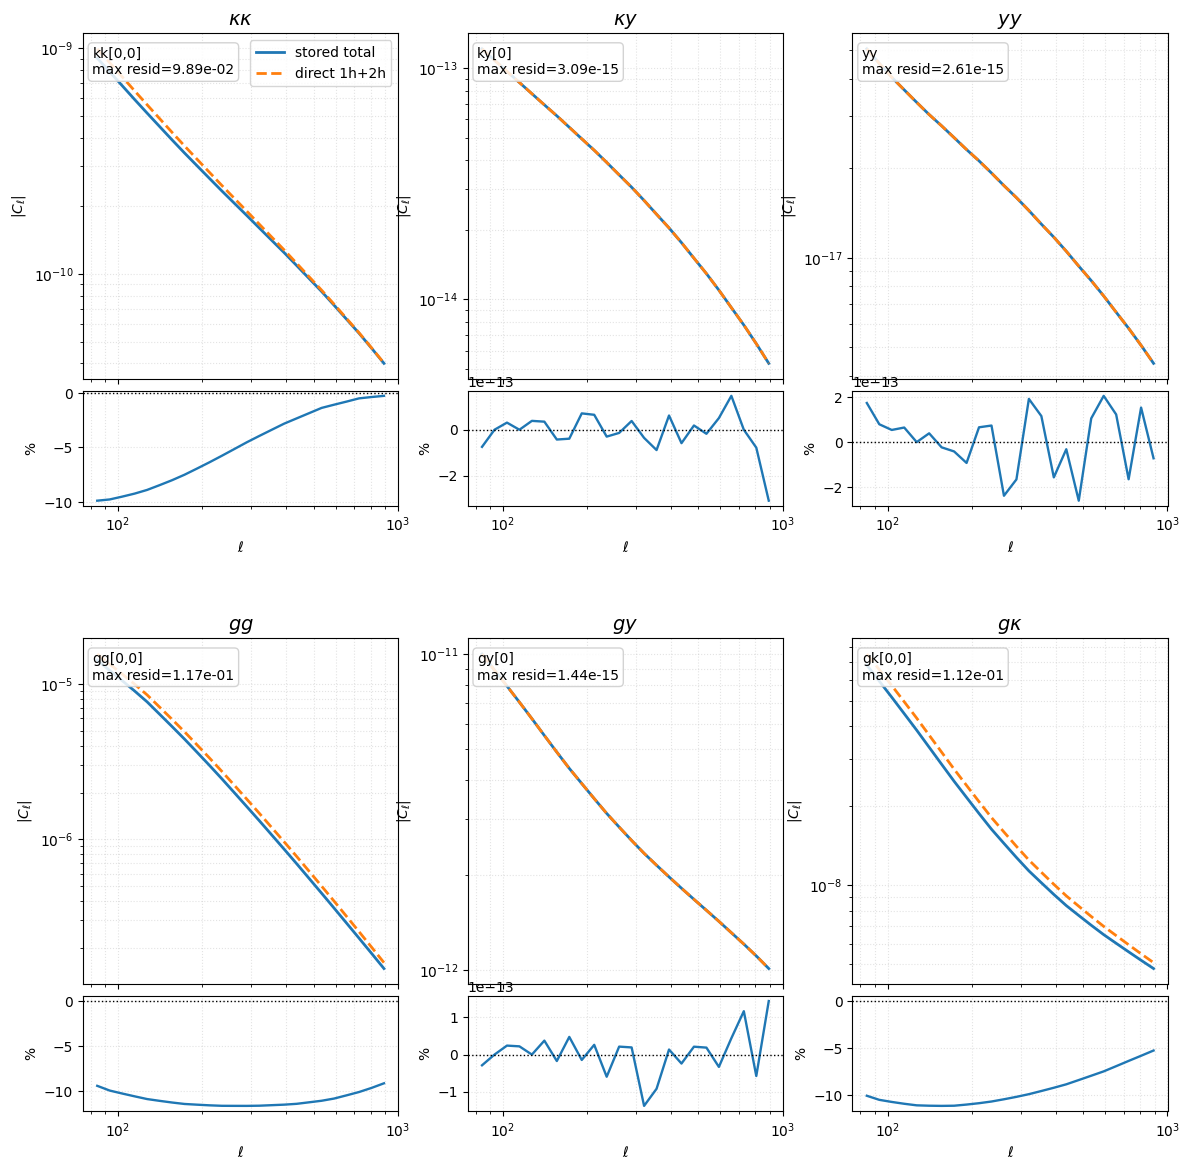

/tmp/ipykernel_273299/3401311558.py:375: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/dl_comparison_corrected2.png


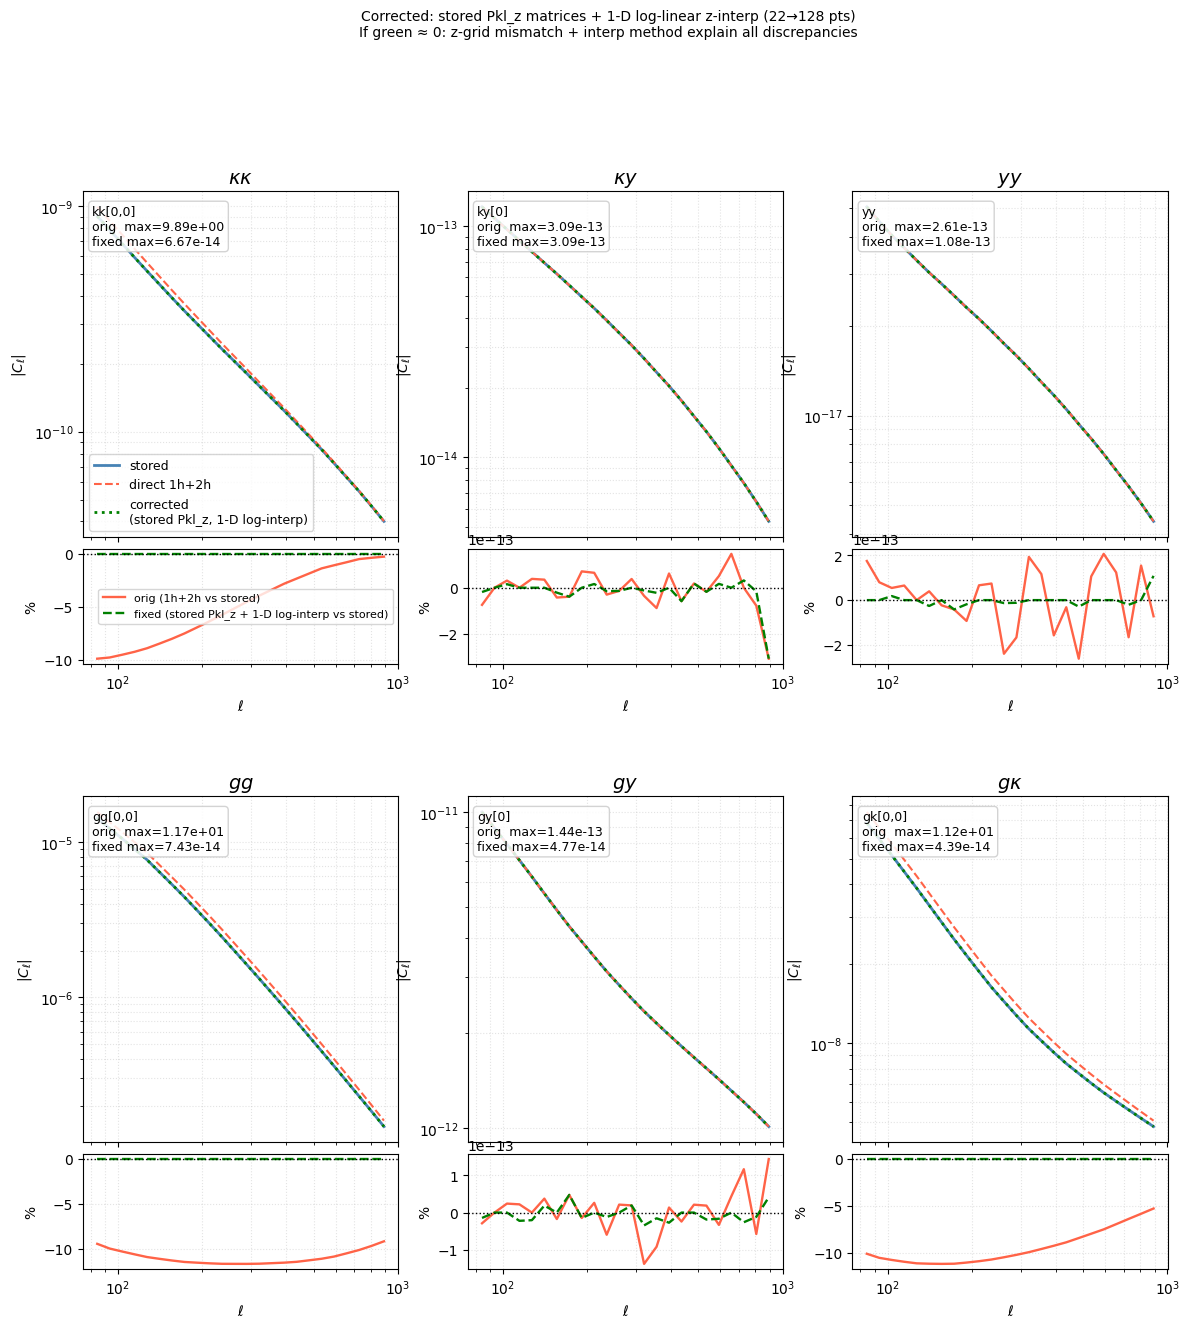

In [52]:
# -----------------------------------------------------------------------------
# Basic arrays / kernels
# -----------------------------------------------------------------------------
ell_th   = np.asarray(Cls_test.ell_array)
efac     = ell_th * (ell_th + 1.0) / (2.0 * np.pi)

z_pk     = np.asarray(Cls_test.z_array)
z_cls    = np.asarray(Cls_test.z_array_for_Cls)
chi_cls  = np.asarray(Cls_test.chi_array_for_Cls)
dchi_cls = np.asarray(Cls_test.dchi_dz_array_for_Cls)
k_pk     = np.asarray(Cls_test.kPk_array)

Bl = np.exp(-0.5 * ell_th * (ell_th + 1.0) * float(Cls_test.sig_beam) ** 2)

Wk = np.asarray(Cls_test.Wk_mat)
mult = np.asarray(Cls_test.mult_shear_bias_array)
Wk_eff = np.array([
    (1.0 + mult[jb]) * Wk[jb] / np.maximum(chi_cls**2, 1e-10)
    for jb in range(Cls_test.nbins)
])

Wy_eff = np.asarray(Cls_test.Wy_array) / np.maximum(chi_cls**2, 1e-10)

if getattr(Cls_test, "model_galaxies", False):
    Wg = np.asarray(Cls_test.Wg_mat)
    Wg_eff = np.array([
        Wg[jb] / np.maximum(dchi_cls * chi_cls**2, 1e-10)
        for jb in range(Cls_test.nbins_lens)
    ])
else:
    Wg_eff = None

# -----------------------------------------------------------------------------
# Direct Limber projector from P(k,z) -> D_l
# -----------------------------------------------------------------------------
def project_dl_from_pk(Pkz_kz, W1, W2, beam_pow=0):
    Pkz = np.maximum(np.asarray(Pkz_kz), 1e-100)

    lkpk = np.log(k_pk)
    lz_pk = np.log(np.maximum(z_pk, 1e-10))
    lz_cls = np.log(np.maximum(z_cls, 1e-10))

    pk_zcls = np.vstack([
        np.exp(np.interp(lz_cls, lz_pk, np.log(np.maximum(Pkz[ik, :], 1e-100))))
        for ik in range(len(k_pk))
    ])  # (nk, nz_cls)

    log_pk_zcls = np.log(np.maximum(pk_zcls, 1e-100))
    k_ell_mat = np.outer(ell_th + 0.5, 1.0 / np.maximum(chi_cls, 1.0))
    log_k_ell = np.log(np.maximum(k_ell_mat, 1e-100))

    pk_lz = np.zeros((len(ell_th), len(z_cls)))
    for iz in range(len(z_cls)):
        pk_lz[:, iz] = np.exp(
            np.interp(log_k_ell[:, iz], lkpk, log_pk_zcls[:, iz])
        )

    if beam_pow == 1:
        pk_lz *= Bl[:, None]
    elif beam_pow == 2:
        pk_lz *= (Bl**2)[:, None]

    integrand = (W1 * W2 * chi_cls**2 * dchi_cls)[None, :] * pk_lz
    cl = np.trapezoid(integrand, z_cls, axis=1)
    dl = efac * cl
    return dl

# -----------------------------------------------------------------------------
# 3D totals built as raw 1h + 2h
# -----------------------------------------------------------------------------
def _yy_total_pk():
    return np.asarray(Cls_test.Pyy_1h_kz_mat) + np.asarray(Cls_test.Pyy_2h_kz_mat)

def _kk_total_pk():
    return np.asarray(Cls_test.Pmm_dmb_1h_kz_mat) + np.asarray(Cls_test.Pmm_dmb_2h_kz_mat)

def _ky_total_pk():
    return np.asarray(Cls_test.Pym_1h_kz_mat) + np.asarray(Cls_test.Pym_2h_kz_mat)

def _gy_total_pk():
    return np.asarray(Cls_test.Pgy_1h_kz_mat) + np.asarray(Cls_test.Pgy_2h_kz_mat)

def _gk_total_pk():
    return np.asarray(Cls_test.Pgm_1h_kz_mat) + np.asarray(Cls_test.Pgm_2h_kz_mat)

def _gg_total_pk():
    return np.asarray(Cls_test.Pgg_1h_kz_mat) + np.asarray(Cls_test.Pgg_2h_kz_mat)

# -----------------------------------------------------------------------------
# Stored signal-only totals from class
# -----------------------------------------------------------------------------
def get_stored_dl(Cl_obj, key):
    if key == 'kk':
        return np.asarray(Cl_obj.Cl_kappa_kappa_tot_mat) * efac[:, None, None]
    elif key == 'ky':
        return np.asarray(Cl_obj.Cl_kappa_y_tot_mat) * efac[:, None]
    elif key == 'gg':
        return np.asarray(Cl_obj.Cl_gal_gal_tot_mat) * efac[:, None, None]
    elif key == 'gy':
        return np.asarray(Cl_obj.Cl_gal_y_tot_mat) * efac[:, None]
    elif key == 'gk':
        return np.asarray(Cl_obj.Cl_gal_kappa_tot_mat) * efac[:, None, None]
    elif key == 'yy':
        if hasattr(Cl_obj, "Cl_y_y_signal_mat"):
            return np.asarray(Cl_obj.Cl_y_y_signal_mat) * efac
        _noise_data = np.loadtxt(analysis_dict['yy_noise_ell_fname'])
        _yy_noise = np.interp(ell_th, _noise_data[:, 0], _noise_data[:, 1])
        return (np.asarray(Cl_obj.Cl_y_y_tot_mat) - _yy_noise) * efac
    else:
        raise ValueError(f"Unknown key: {key}")

# -----------------------------------------------------------------------------
# Direct projected D_l from raw 1h+2h
# -----------------------------------------------------------------------------
def get_direct_dl_from_pk(key):
    if key == 'yy':
        return project_dl_from_pk(_yy_total_pk(), Wy_eff, Wy_eff, beam_pow=2)

    elif key == 'ky':
        arr = []
        Ptot = _ky_total_pk()
        for jb in range(Cls_test.nbins):
            arr.append(project_dl_from_pk(Ptot, Wk_eff[jb], Wy_eff, beam_pow=1))
        return np.array(arr).T

    elif key == 'kk':
        arr = []
        Ptot = _kk_total_pk()
        for jb1 in range(Cls_test.nbins):
            row = []
            for jb2 in range(Cls_test.nbins):
                row.append(project_dl_from_pk(Ptot, Wk_eff[jb1], Wk_eff[jb2], beam_pow=0))
            arr.append(row)
        return np.transpose(np.array(arr), (2, 0, 1))

    elif key == 'gy':
        arr = []
        Ptot = _gy_total_pk()
        for jb in range(Cls_test.nbins_lens):
            arr.append(project_dl_from_pk(Ptot, Wg_eff[jb], Wy_eff, beam_pow=1))
        return np.array(arr).T

    elif key == 'gk':
        arr = []
        Ptot = _gk_total_pk()
        for jb1 in range(Cls_test.nbins_lens):
            row = []
            for jb2 in range(Cls_test.nbins):
                row.append(project_dl_from_pk(Ptot, Wg_eff[jb1], Wk_eff[jb2], beam_pow=0))
            arr.append(row)
        return np.transpose(np.array(arr), (2, 0, 1))

    elif key == 'gg':
        arr = []
        Ptot = _gg_total_pk()
        for jb1 in range(Cls_test.nbins_lens):
            row = []
            for jb2 in range(Cls_test.nbins_lens):
                row.append(project_dl_from_pk(Ptot, Wg_eff[jb1], Wg_eff[jb2], beam_pow=0))
            arr.append(row)
        return np.transpose(np.array(arr), (2, 0, 1))

    else:
        raise ValueError(f"Unknown key: {key}")

# -----------------------------------------------------------------------------
# Slice helper
# -----------------------------------------------------------------------------
def extract_curve(arr, key, idx1=0, idx2=None):
    if key == 'yy':
        return np.asarray(arr)
    elif key in ['ky', 'gy']:
        return np.asarray(arr)[:, idx1]
    elif key in ['kk', 'gg']:
        if idx2 is None:
            idx2 = idx1
        return np.asarray(arr)[:, idx1, idx2]
    elif key == 'gk':
        if idx2 is None:
            idx2 = 0
        return np.asarray(arr)[:, idx1, idx2]
    else:
        raise ValueError(f"Unknown key: {key}")

# -----------------------------------------------------------------------------
# Plot specs
# -----------------------------------------------------------------------------
probe_specs = [
    ('kk', 0, 0, r'$\kappa\kappa$'),
    ('ky', 0, None, r'$\kappa y$'),
    ('yy', None, None, r'$yy$'),
    ('gg', 0, 0, r'$gg$'),
    ('gy', 0, None, r'$gy$'),
    ('gk', 0, 0, r'$g\kappa$'),
]

# -----------------------------------------------------------------------------
# 3x2 figure with nested subgrids
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(14, 14))
outer = fig.add_gridspec(2, 3, hspace=0.28, wspace=0.22)

for n, (key, idx1, idx2, title) in enumerate(probe_specs):
    i, j = divmod(n, 3 )
    inner = outer[i, j].subgridspec(2, 1, height_ratios=[3.0, 1.0], hspace=0.05)

    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    stored_all = get_stored_dl(Cls_test, key)
    direct_all = get_direct_dl_from_pk(key)

    dl_stored = extract_curve(stored_all, key, 0 if idx1 is None else idx1, idx2)
    dl_direct = extract_curve(direct_all, key, 0 if idx1 is None else idx1, idx2)

    cl_stored = np.abs(dl_stored / efac)
    cl_direct = np.abs(dl_direct / efac)

    with np.errstate(divide='ignore', invalid='ignore'):
        resid = np.where(np.abs(dl_stored) > 0, (dl_stored - dl_direct) / dl_stored * 100.0, np.nan)
        max_resid = np.nanmax(np.abs((dl_stored - dl_direct) / dl_stored))

    # Top panel
    ax_top.loglog(ell_th, cl_stored, lw=2, label='stored total')
    ax_top.loglog(ell_th, cl_direct, '--', lw=2, label='direct 1h+2h')
    ax_top.set_title(title, fontsize=14)
    ax_top.set_ylabel(r'$|C_\ell|$')
    ax_top.grid(True, which='both', ls=':', alpha=0.35)
    ax_top.tick_params(axis='x', labelbottom=False)

    # label box
    if key == 'yy':
        label = 'yy'
    elif key in ['ky', 'gy']:
        label = f'{key}[{idx1}]'
    else:
        label = f'{key}[{idx1},{idx2}]'

    ax_top.text(
        0.03, 0.96,
        f'{label}\nmax resid={max_resid:.2e}',
        transform=ax_top.transAxes,
        va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.8')
    )

    # Bottom residual panel
    ax_bot.semilogx(ell_th, resid, lw=1.7)
    ax_bot.axhline(0.0, color='k', ls=':', lw=1)
    ax_bot.set_xlabel(r'$\ell$')
    ax_bot.set_ylabel('%')
    ax_bot.grid(True, which='both', ls=':', alpha=0.35)

    if n == 0:
        ax_top.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig(FIGDIR / 'dl_comparison.png', dpi=300)
print(f"Saved figure to {FIGDIR / 'dl_comparison.png'}")
plt.show()

# =============================================================================
# Verify the source of stored-vs-direct discrepancy
#
# Key insight: the stored path builds Pkl_z_mat[nell, 22] at chi_array k-values
# (correct power spectrum, correct beam) then uses a 2-D cubic spline in
# log(P) space to reach 128 z-points.  The direct path uses chi_for_Cls k-values
# (128 pts) from the start.
#
# Test: take the stored Pkl_z_mat as-is and only replace the 2-D cubic spline
# with a 1-D log-linear z-interp → if residuals → ~0 the z-grid mismatch plus
# interpolation method fully explains the discrepancy.
# =============================================================================

z_halo   = z_pk                               # (nz=22)   alias
chi_halo = np.asarray(Cls_test.chi_array)     # (nz=22)

# ── one function that covers all probes ──────────────────────────────────────
def project_dl_from_pkl_z(Pkl_z_mat, W1, W2):
    """
    Take a pre-built Pkl_z matrix (nell, nz=22) that already contains:
      - the correct 3-D power spectrum (Pmm_tot / Pym_tot / Pyy_tot / …)
      - beam factor (if applicable)
      - Limber k evaluated at chi_array (22-pt halo grid)

    1-D log-linearly z-interpolate from z_halo (22) → z_cls (128),
    then integrate with the 128-pt weights.

    This mirrors everything the stored path does EXCEPT the interpolation
    method (1-D log-linear here vs 2-D cubic spline in stored).
    """
    Pkl = np.maximum(np.asarray(Pkl_z_mat), 1e-100)     # (nell, 22)
    log_Pkl = np.log(Pkl)

    # 1-D log-linear z-interp: z_halo (22) → z_cls (128)
    Pkl_128 = np.exp(np.array([
        np.interp(z_cls, z_halo, log_Pkl[il]) for il in range(len(ell_th))
    ]))                                                  # (nell, 128)

    integrand = (W1 * W2 * chi_cls**2 * dchi_cls)[None, :] * Pkl_128
    return efac * np.trapezoid(integrand, z_cls, axis=1)

# ── corrected direct using stored Pkl_z matrices ─────────────────────────────
dl_corr2 = {
    # kk: Pkmm_lz_mat  = get_P_lz(Pmm_tot)            no beam
    'kk': project_dl_from_pkl_z(Cls_test.Pkmm_lz_mat,    Wk_eff[0], Wk_eff[0]),
    # ky: Pkym_lz_mat  = get_P_lz(Pym_tot) * Bl       beam^1 already baked in
    'ky': project_dl_from_pkl_z(Cls_test.Pkym_lz_mat,    Wk_eff[0], Wy_eff),
    # yy: Pkyy_lz_mat  = get_Pkyy_lz(Pyy_tot)         beam^2 already baked in
    'yy': project_dl_from_pkl_z(Cls_test.Pkyy_lz_mat,    Wy_eff,    Wy_eff),
    # gg: Pkgg_lz_mat  = get_P_lz(Pgg_tot)             no beam
    'gg': project_dl_from_pkl_z(Cls_test.Pkgg_lz_mat,    Wg_eff[0], Wg_eff[0]),
    # gy: Pkgy_lz_mat  = get_P_lz(Pgy_tot) * Bl       beam^1 already baked in
    'gy': project_dl_from_pkl_z(Cls_test.Pkgy_lz_mat,    Wg_eff[0], Wy_eff),
    # gk: Pkgm_lz_mat  = get_P_lz(Pgm_tot)             no beam
    'gk': project_dl_from_pkl_z(Cls_test.Pkgm_lz_mat,    Wg_eff[0], Wk_eff[0]),
}

# ── plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 14))
outer = fig.add_gridspec(2, 3, hspace=0.28, wspace=0.22)

for n, (key, idx1, idx2, title) in enumerate(probe_specs):
    i, j = divmod(n, 3)
    inner  = outer[i, j].subgridspec(2, 1, height_ratios=[3.0, 1.0], hspace=0.05)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    dl_stored = extract_curve(get_stored_dl(Cls_test, key), key,
                              0 if idx1 is None else idx1, idx2)
    dl_direct = extract_curve(get_direct_dl_from_pk(key), key,
                              0 if idx1 is None else idx1, idx2)
    dl_fixed  = dl_corr2[key]

    ax_top.loglog(ell_th, np.abs(dl_stored / efac), lw=2,        color='steelblue', label='stored')
    ax_top.loglog(ell_th, np.abs(dl_direct / efac), '--', lw=1.5, color='tomato',   label='direct 1h+2h')
    ax_top.loglog(ell_th, np.abs(dl_fixed  / efac), ':',  lw=2,   color='green',    label='corrected\n(stored Pkl_z, 1-D log-interp)')
    ax_top.set_title(title, fontsize=14)
    ax_top.set_ylabel(r'$|C_\ell|$')
    ax_top.grid(True, which='both', ls=':', alpha=0.35)
    ax_top.tick_params(axis='x', labelbottom=False)
    if n == 0:
        ax_top.legend(fontsize=9, loc='lower left')

    with np.errstate(divide='ignore', invalid='ignore'):
        safe    = np.abs(dl_stored) > 0
        r_orig  = np.where(safe, (dl_stored - dl_direct) / dl_stored * 100.0, np.nan)
        r_fixed = np.where(safe, (dl_stored - dl_fixed)  / dl_stored * 100.0, np.nan)

    label_key = ('yy' if key == 'yy'
                 else f'{key}[{0 if idx1 is None else idx1}]' if key in ['ky', 'gy']
                 else f'{key}[{idx1},{idx2}]')
    ax_top.text(0.03, 0.96,
                f'{label_key}\n'
                f'orig  max={np.nanmax(np.abs(r_orig)):.2e}\n'
                f'fixed max={np.nanmax(np.abs(r_fixed)):.2e}',
                transform=ax_top.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.8'))

    ax_bot.semilogx(ell_th, r_orig,  lw=1.7, color='tomato', label='orig (1h+2h vs stored)')
    ax_bot.semilogx(ell_th, r_fixed, lw=1.7, color='green',  ls='--',
                    label='fixed (stored Pkl_z + 1-D log-interp vs stored)')
    ax_bot.axhline(0.0, color='k', ls=':', lw=1)
    ax_bot.set_xlabel(r'$\ell$')
    ax_bot.set_ylabel('%')
    ax_bot.grid(True, which='both', ls=':', alpha=0.35)
    if n == 0:
        ax_bot.legend(fontsize=8)

plt.suptitle(
    'Corrected: stored Pkl_z matrices + 1-D log-linear z-interp (22→128 pts)\n'
    'If green ≈ 0: z-grid mismatch + interp method explain all discrepancies',
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig(FIGDIR / 'dl_comparison_corrected2.png', dpi=300, bbox_inches='tight')
print(f"Saved → {FIGDIR / 'dl_comparison_corrected2.png'}")
plt.show()


In [55]:
def get_cov_fromdv(probes_all):                 
    # ── Build ordered list of (probe, [b1, b2]) entries ──────────────────────────                          
    bin_comb_all_wprobe = []                
    for probe in probes_all:                                                                                 
        for b1, b2 in cov_test.Cl_result_dict[probe]['bin_combs']:                                           
            # for auto-probes keep upper triangle only                                                       
            if probe in ['kk', 'gg', 'yy'] and b2 < b1:                                                            
                continue                        
            bin_comb_all_wprobe.append((probe, [b1, b2]))                                                    
                                                                                                            
    count_all_probes = len(bin_comb_all_wprobe)                                                              
    nell             = len(ell_th)                                                                           
    nell_all         = nell * count_all_probes                                                               
    print(f"N probe×bin combinations: {count_all_probes},  data vector length: {nell_all}")                  
                                                
    # ── Assemble covariance matrix ────────────────────────────────────────────────                         
    cov_mat_all = np.zeros((nell_all, nell_all))
    for jp1, (probe1, (b1, b2)) in enumerate(bin_comb_all_wprobe):                                           
        for jp2, (probe2, (b3, b4)) in enumerate(bin_comb_all_wprobe):                                       
            sl1 = slice(jp1 * nell, (jp1 + 1) * nell)                                                        
            sl2 = slice(jp2 * nell, (jp2 + 1) * nell)                                                        
            key_fwd = f'{probe1}_{probe2}'                                                                   
            key_rev = f'{probe2}_{probe1}'                                                                   
            bin_fwd = f'bin_{b1}_{b2}_{b3}_{b4}'                                                             
            bin_rev = f'bin_{b3}_{b4}_{b1}_{b2}'                                                             
            if key_fwd in cov_test.covtot_dict and bin_fwd in cov_test.covtot_dict[key_fwd]:
                cov_mat_all[sl1, sl2] = cov_test.covtot_dict[key_fwd][bin_fwd]                               
            else:                               
                cov_mat_all[sl1, sl2] = cov_test.covtot_dict[key_rev][bin_rev]   
    return cov_mat_all, bin_comb_all_wprobe, count_all_probes, nell                            
                                                                                                                                                                                                    


N probe×bin combinations: 21,  data vector length: 504

Diagnostic suite: combined covariance

--- combined covariance (symmetrized input) ---
shape                : (504, 504)
max asymmetry        : 1.849e-32
min diag             : 4.683e-38
max diag             : 1.365e-12
n negative diag      : 0
lambda_min           : -1.919e-33
lambda_max           : 2.442e-12
n negative eigenvals : 4
condition number-ish : 1.273e+21
trace                : 2.576e-11
frobenius norm       : 4.381e-12

Correlation matrix diagnostics

--- combined covariance correlation ---
shape                : (504, 504)
max asymmetry        : 0.000e+00
min diag             : 1.000e+00
max diag             : 1.000e+00
n negative diag      : 0
lambda_min           : 3.673e-02
lambda_max           : 1.961e+01
n negative eigenvals : 0
condition number-ish : 5.338e+02
trace                : 5.040e+02
frobenius norm       : 3.696e+01

Diagonal/off-diagonal interpolation

--- diagonal vs off-diagonal ---
raw C   : lambda

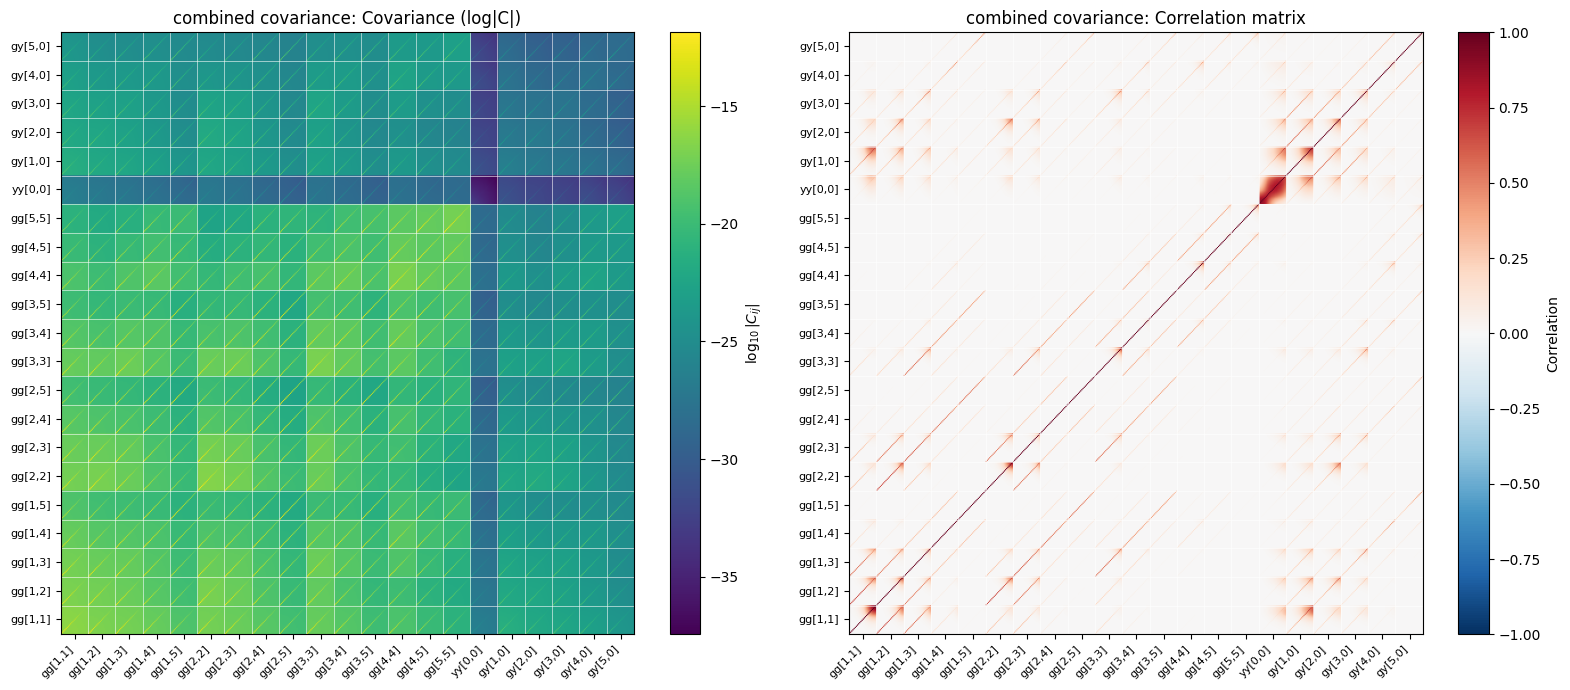

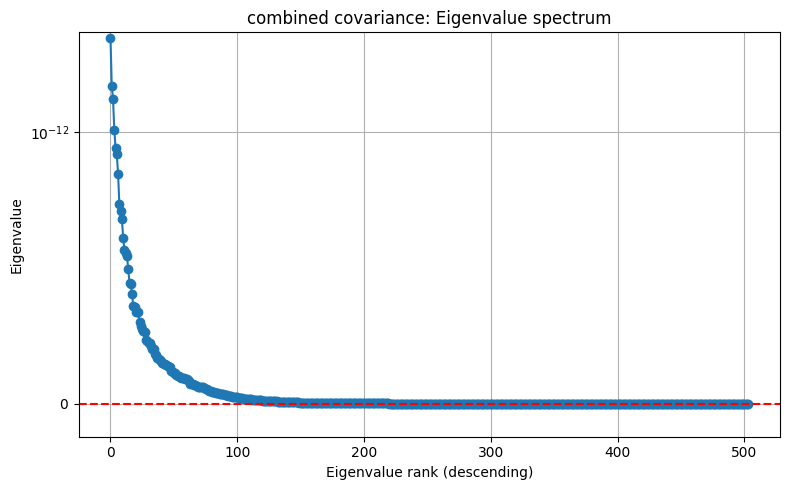

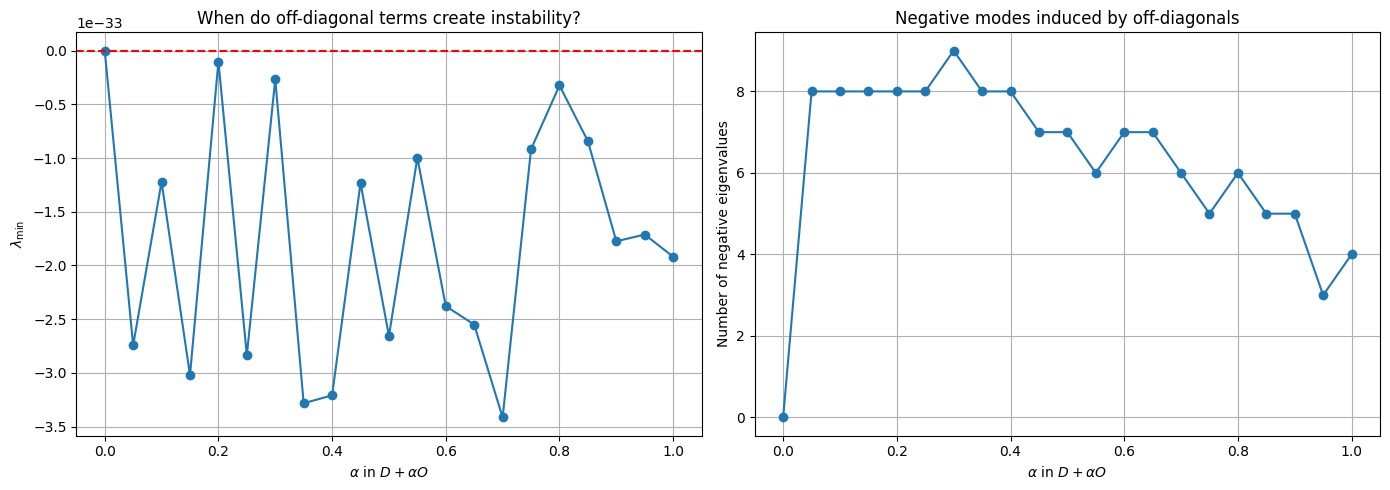

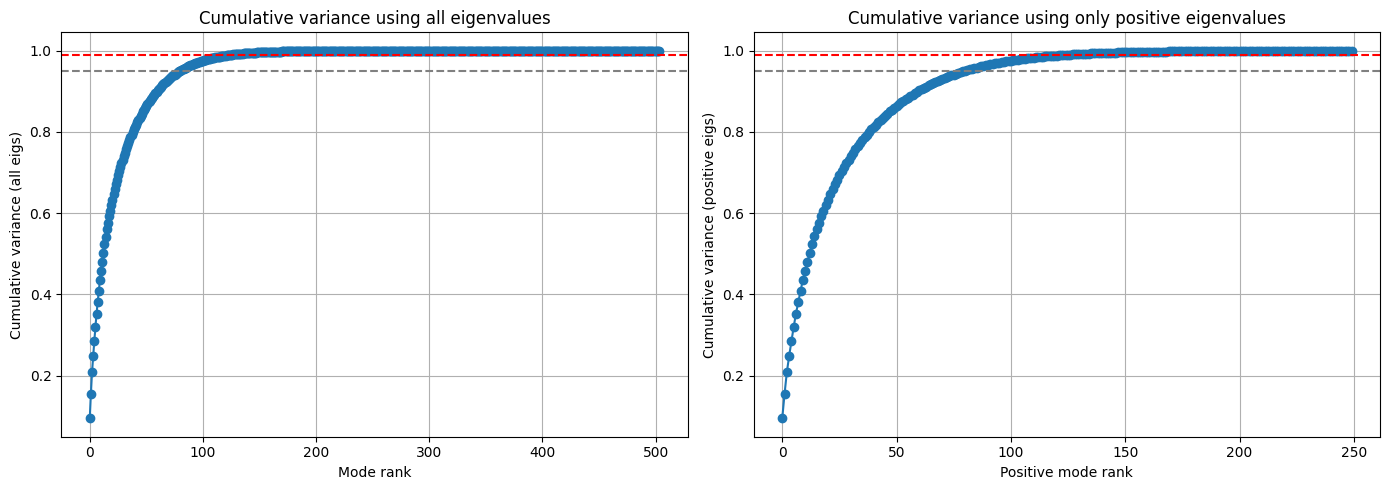

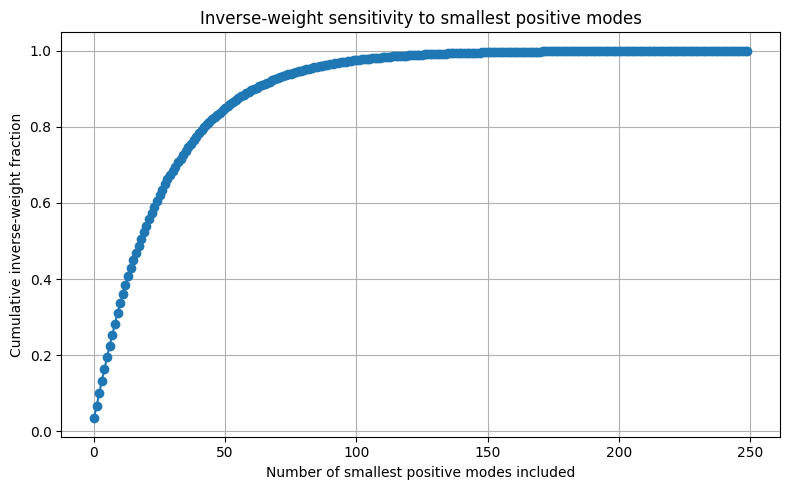

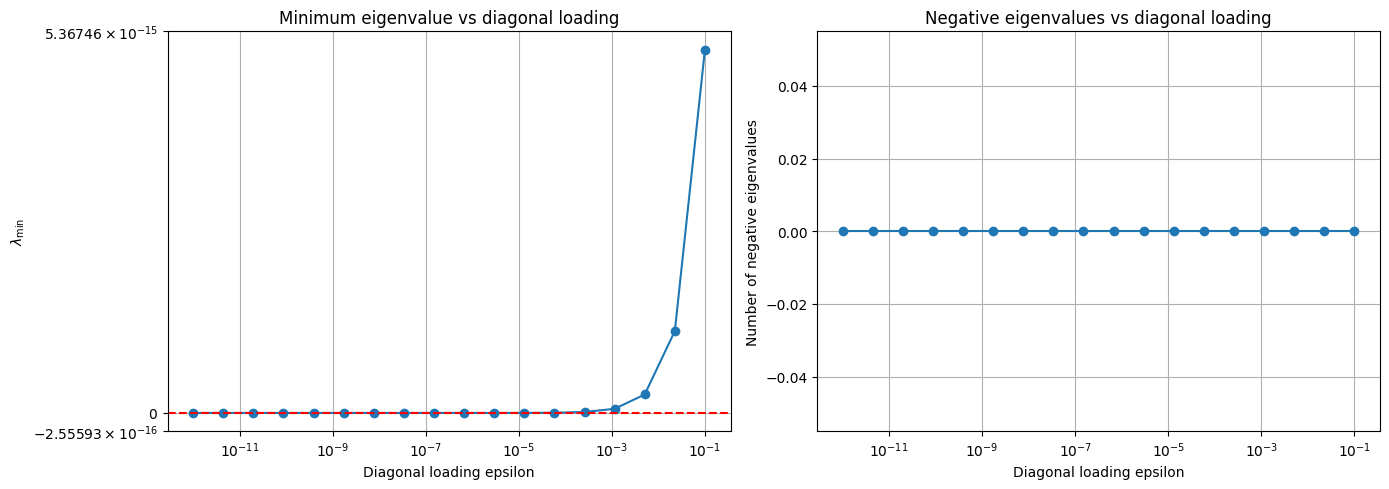

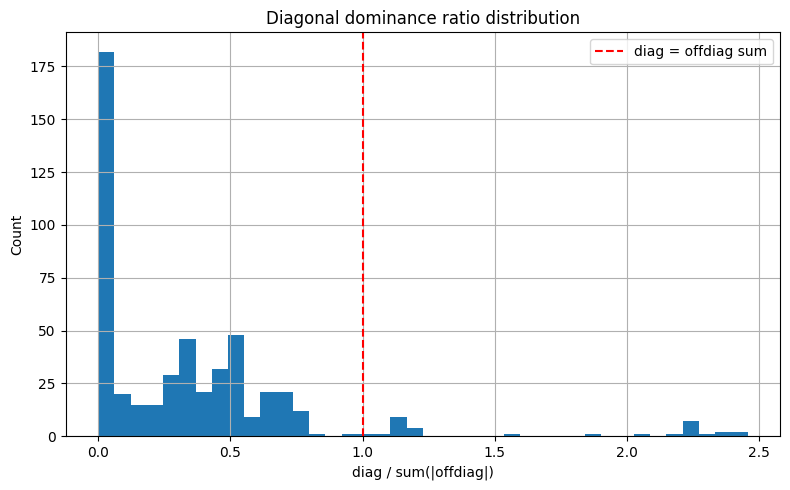

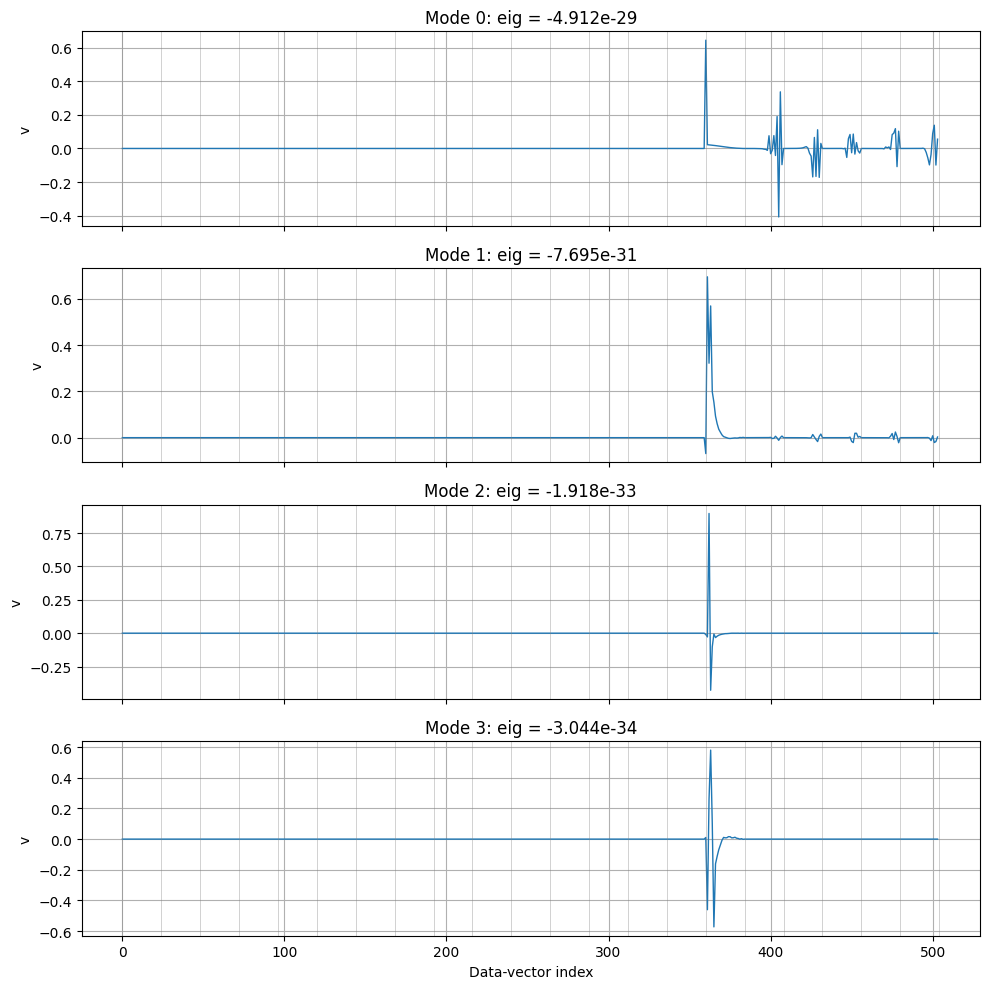

-1.9189427931799934e-33 0.05 3.197300760469343e-15 [{'mode_rank': 0, 'eigval': np.float64(-4.9117903878568667e-29), 'block_fraction': array([3.33208289e-12, 2.96806121e-13, 2.13289750e-13, 2.76528777e-13,
       2.52084370e-13, 1.68843085e-13, 8.57314408e-14, 1.84619133e-13,
       2.11381176e-13, 7.72666114e-15, 4.21168194e-14, 3.47574139e-14,
       5.83477141e-14, 1.35260179e-13, 4.10216341e-14, 4.20759200e-01,
       3.41287007e-01, 1.07100369e-01, 2.45922533e-02, 5.17827130e-02,
       5.44784579e-02]), 'top_blocks': [('yy[0,0]', np.float64(0.4207591997838863)), ('gy[1,0]', np.float64(0.34128700667288975)), ('gy[2,0]', np.float64(0.10710036930407638)), ('gy[5,0]', np.float64(0.054478457902918526)), ('gy[4,0]', np.float64(0.05178271302159421))]}, {'mode_rank': 1, 'eigval': np.float64(-7.6950090365630355e-31), 'block_fraction': array([2.34039214e-15, 9.85014472e-15, 1.08663629e-14, 1.28147455e-14,
       1.05036480e-14, 7.40828184e-16, 1.17827289e-15, 1.16767237e-15,
       2.405927

In [56]:
from pathlib import Path

def covariance_diagnostic_suite(
    C,
    d=None,
    name="combined covariance",
    tick_labels=None,
    nell=None,
    figdir=None,
    save_tag="cov_diag",
    n_modes_report=10,
    eps_pos=1e-16,
    diag_load_grid=None,
    make_plots=True,
):
    """
    Full covariance diagnostic suite.

    Parameters
    ----------
    C : (N, N) array
        Covariance matrix.
    d : (N,) array or None
        Data vector.
    tick_labels : list[str] or None
        Labels for each probe/bin block.
    nell : int or None
        Number of ell bins per block.
    figdir : pathlib.Path or str or None
        Directory to save plots. If None, plots are not saved.
    save_tag : str
        Prefix for saved plot names.
    n_modes_report : int
        Number of smallest/most negative modes to inspect.
    eps_pos : float
        Threshold for treating eigenvalues as positive.
    diag_load_grid : array or None
        Grid of epsilon values for diagonal loading test.
    make_plots : bool
        Whether to make plots.

    Returns
    -------
    results : dict
    """

    C = np.asarray(C, dtype=float)
    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError("C must be a square matrix")

    n = C.shape[0]

    if d is not None:
        d = np.asarray(d, dtype=float).ravel()
        if len(d) != n:
            raise ValueError("Length of d must match matrix dimension")

    if diag_load_grid is None:
        diag_load_grid = np.logspace(-12, -1, 18)

    if figdir is not None:
        figdir = Path(figdir)
        figdir.mkdir(parents=True, exist_ok=True)

    def savefig(name):
        if figdir is not None:
            plt.savefig(figdir / f"{save_tag}_{name}.png", dpi=200, bbox_inches="tight")

    def basic_cov_diagnostics(M, label="matrix"):
        M = np.asarray(M)
        asym = np.max(np.abs(M - M.T))
        diag = np.diag(M)
        evals = np.linalg.eigvalsh(0.5 * (M + M.T))

        out = {
            "shape": M.shape,
            "max_asymmetry": asym,
            "min_diag": diag.min(),
            "max_diag": diag.max(),
            "n_negative_diag": int(np.sum(diag < 0)),
            "lambda_min": evals.min(),
            "lambda_max": evals.max(),
            "n_negative_eigs": int(np.sum(evals < 0)),
            "trace": np.trace(M),
            "fro_norm": np.linalg.norm(M, ord="fro"),
        }

        cond_like = evals.max() / max(np.abs(evals.min()), 1e-300)

        print(f"\n--- {label} ---")
        print(f"shape                : {out['shape']}")
        print(f"max asymmetry        : {out['max_asymmetry']:.3e}")
        print(f"min diag             : {out['min_diag']:.3e}")
        print(f"max diag             : {out['max_diag']:.3e}")
        print(f"n negative diag      : {out['n_negative_diag']}")
        print(f"lambda_min           : {out['lambda_min']:.3e}")
        print(f"lambda_max           : {out['lambda_max']:.3e}")
        print(f"n negative eigenvals : {out['n_negative_eigs']}")
        print(f"condition number-ish : {cond_like:.3e}")
        print(f"trace                : {out['trace']:.3e}")
        print(f"frobenius norm       : {out['fro_norm']:.3e}")

        out["condition_like"] = cond_like
        return out

    def correlation_matrix(M):
        M = 0.5 * (M + M.T)
        raw_diag = np.diag(M)
        d = np.sqrt(np.where(raw_diag > 0, raw_diag, np.nan))
        d_safe = np.where(np.isfinite(d) & (d > 0), d, 1.0)
        R = M / np.outer(d_safe, d_safe)
        R = 0.5 * (R + R.T)
        return R

    def diagonal_offdiagonal_tests(M):
        M = 0.5 * (M + M.T)
        D = np.diag(np.diag(M))
        O = M - D

        evals_M = np.linalg.eigvalsh(M)
        evals_D = np.linalg.eigvalsh(D)

        print("\n--- diagonal vs off-diagonal ---")
        print(f"raw C   : lambda_min = {evals_M.min():.3e}, n_neg = {np.sum(evals_M < 0)}")
        print(f"diag D  : lambda_min = {evals_D.min():.3e}, n_neg = {np.sum(evals_D < 0)}")

        alphas = np.linspace(0, 1, 21)
        lam_mins = []
        n_negs = []

        for a in alphas:
            Ca = D + a * O
            e = np.linalg.eigvalsh(Ca)
            lam_mins.append(e.min())
            n_negs.append(np.sum(e < 0))

        lam_mins = np.array(lam_mins)
        n_negs = np.array(n_negs)

        first_neg_alpha = None
        for a, nn in zip(alphas, n_negs):
            if nn > 0:
                first_neg_alpha = a
                break

        if first_neg_alpha is None:
            print("No negative eigenvalues appear along D + alpha O for alpha in [0,1].")
        else:
            print(f"First alpha where negative modes appear: {first_neg_alpha:.2f}")

        return {
            "D": D,
            "O": O,
            "alphas": alphas,
            "lam_mins": lam_mins,
            "n_negs": n_negs,
            "first_neg_alpha": first_neg_alpha,
        }

    def eigenmode_structure(M, k=5):
        M = 0.5 * (M + M.T)
        evals, evecs = np.linalg.eigh(M)
        idx = np.argsort(evals)   # smallest first
        evals = evals[idx]
        evecs = evecs[:, idx]

        out = []
        for i in range(min(k, len(evals))):
            v = evecs[:, i]
            w = v**2
            dominant_frac = w.max()
            eff_support = 1.0 / np.sum(w**2)
            dominant_idx = np.argmax(w)
            out.append({
                "mode_rank": i,
                "eigval": evals[i],
                "dominant_idx": int(dominant_idx),
                "dominant_frac": float(dominant_frac),
                "eff_support": float(eff_support),
                "vector": v,
            })
        return out

    def block_contribution_of_mode(v, tick_labels, nell):
        nblocks = len(tick_labels)
        power = []
        for i in range(nblocks):
            sl = slice(i * nell, (i + 1) * nell)
            power.append(np.sum(v[sl]**2))
        power = np.array(power)
        if power.sum() > 0:
            power = power / power.sum()
        return power

    def cumulative_variance_info(M):
        M = 0.5 * (M + M.T)
        evals = np.linalg.eigvalsh(M)
        evals_sorted = np.sort(evals)[::-1]
        total = np.sum(evals_sorted)
        if np.abs(total) < 1e-300:
            cum = np.full_like(evals_sorted, np.nan)
        else:
            cum = np.cumsum(evals_sorted) / total
        return evals_sorted, cum

    def cumulative_positive_variance_info(M):
        M = 0.5 * (M + M.T)
        evals = np.linalg.eigvalsh(M)
        pos = evals[evals > eps_pos]
        pos = np.sort(pos)[::-1]
        if len(pos) == 0:
            return pos, np.array([])
        cum = np.cumsum(pos) / np.sum(pos)
        return pos, cum

    def inverse_weight_spectrum(M):
        M = 0.5 * (M + M.T)
        evals = np.linalg.eigvalsh(M)
        pos = evals[evals > eps_pos]
        pos = np.sort(pos)[::-1]
        if len(pos) == 0:
            return pos, np.array([]), np.array([])
        inv_weights = 1.0 / pos
        cum_inv = np.cumsum(inv_weights[::-1]) / np.sum(inv_weights)
        return pos, inv_weights, cum_inv

    def mode_projection_diagnostics(M, d, eps=1e-14):
        M = 0.5 * (M + M.T)
        evals, evecs = np.linalg.eigh(M)
        idx = np.argsort(evals)[::-1]
        evals = evals[idx]
        evecs = evecs[:, idx]

        amps = evecs.T @ d
        chi_like = np.full_like(evals, np.nan, dtype=float)
        mask = evals > eps
        chi_like[mask] = amps[mask]**2 / evals[mask]

        return {
            "evals": evals,
            "evecs": evecs,
            "amps": amps,
            "amp2": amps**2,
            "chi_like": chi_like,
        }

    def diagonal_dominance_test(M):
        M = 0.5 * (M + M.T)
        diag = np.diag(M)
        offsum = np.sum(np.abs(M), axis=1) - np.abs(diag)
        ratio = diag / np.where(offsum > 0, offsum, 1.0)

        print("\n--- diagonal dominance ---")
        print(f"rows with diag < offdiag sum : {np.sum(diag < offsum)} / {len(diag)}")
        print(f"min diag/offdiag_sum ratio   : {np.min(ratio):.3e}")
        print(f"median diag/offdiag_sum ratio: {np.median(ratio):.3e}")
        print(f"max diag/offdiag_sum ratio   : {np.max(ratio):.3e}")

        return {
            "ratio": ratio,
            "offsum": offsum,
            "n_diag_lt_offsum": int(np.sum(diag < offsum)),
        }

    def nearest_psd_clip(M):
        M = 0.5 * (M + M.T)
        evals, evecs = np.linalg.eigh(M)
        evals_clip = np.clip(evals, 0, None)
        M_psd = (evecs * evals_clip) @ evecs.T
        M_psd = 0.5 * (M_psd + M_psd.T)
        return M_psd, evals, evals_clip

    def diagonal_loading_curve(M, epsilons):
        M = 0.5 * (M + M.T)
        mu = np.mean(np.diag(M))
        out = []
        for eps in epsilons:
            Mreg = M + eps * mu * np.eye(M.shape[0])
            vals = np.linalg.eigvalsh(Mreg)
            out.append({
                "eps": eps,
                "lambda_min": vals.min(),
                "n_neg": int(np.sum(vals < 0)),
            })
        return out

    # ------------------------------------------------------------------
    # Main diagnostics
    # ------------------------------------------------------------------
    print("\n" + "="*100)
    print(f"Diagnostic suite: {name}")
    print("="*100)

    stats_raw = basic_cov_diagnostics(C, label=f"{name} (symmetrized input)")

    R = correlation_matrix(C)

    print("\n" + "="*100)
    print("Correlation matrix diagnostics")
    print("="*100)
    stats_corr = basic_cov_diagnostics(R, label=f"{name} correlation")

    print("\n" + "="*100)
    print("Diagonal/off-diagonal interpolation")
    print("="*100)
    res_do = diagonal_offdiagonal_tests(C)

    print("\n" + "="*100)
    print("Smallest / most negative eigenmodes")
    print("="*100)
    modes = eigenmode_structure(C, k=n_modes_report)
    for m in modes:
        print(
            f"mode {m['mode_rank']:2d}: "
            f"eig={m['eigval']:.3e}, "
            f"dominant_idx={m['dominant_idx']}, "
            f"dominant_frac={m['dominant_frac']:.3f}, "
            f"eff_support={m['eff_support']:.2f}"
        )

    mode_block_info = []
    if tick_labels is not None and nell is not None:
        evals_full, evecs_full = np.linalg.eigh(0.5 * (C + C.T))
        idx_small = np.argsort(evals_full)

        print("\nBlock contributions of problematic modes:")
        for j in range(min(n_modes_report, len(evals_full))):
            lam = evals_full[idx_small[j]]
            v = evecs_full[:, idx_small[j]]
            frac = block_contribution_of_mode(v, tick_labels, nell)
            top = np.argsort(frac)[::-1][:5]

            print(f"\nMode {j}, eig = {lam:.3e}")
            tops = []
            for t in top:
                print(f"   {tick_labels[t]:25s} : {frac[t]:.3f}")
                tops.append((tick_labels[t], frac[t]))

            mode_block_info.append({
                "mode_rank": j,
                "eigval": lam,
                "block_fraction": frac,
                "top_blocks": tops,
            })

    dd = diagonal_dominance_test(C)

    print("\n" + "="*100)
    print("Nearest PSD projection by eigenvalue clipping")
    print("="*100)
    C_psd, evals_raw, evals_clip = nearest_psd_clip(C)
    fro_rel = np.linalg.norm(C_psd - C, ord='fro') / max(np.linalg.norm(C, ord='fro'), 1e-300)
    print(f"relative Frobenius distance to PSD clip : {fro_rel:.3e}")
    print(f"sum of negative eigenvalues             : {np.sum(evals_raw[evals_raw < 0]):.3e}")
    print(f"most negative eigenvalue                : {evals_raw.min():.3e}")
    print(f"number of clipped eigenvalues           : {np.sum(evals_raw < 0)}")

    print("\n" + "="*100)
    print("Variance content")
    print("="*100)
    evals_sorted_all, cum_all = cumulative_variance_info(C)
    pos_evals, cum_pos = cumulative_positive_variance_info(C)

    if len(pos_evals) > 0:
        idx95 = np.searchsorted(cum_pos, 0.95) + 1
        idx99 = np.searchsorted(cum_pos, 0.99) + 1
        print(f"positive PCs needed for 95% variance : {idx95}")
        print(f"positive PCs needed for 99% variance : {idx99}")
        print(f"largest positive eigenvalue          : {pos_evals[0]:.3e}")
        print(f"smallest positive eigenvalue         : {pos_evals[-1]:.3e}")
    else:
        print("No positive eigenvalues found.")

    print("\n" + "="*100)
    print("Inverse-weight sensitivity")
    print("="*100)
    pos2, invw, cuminv = inverse_weight_spectrum(C)
    if len(pos2) > 0:
        print(f"largest positive eigenvalue              : {pos2[0]:.3e}")
        print(f"smallest positive eigenvalue             : {pos2[-1]:.3e}")
        print(f"positive eigenvalue dynamic range        : {pos2[0]/max(pos2[-1],1e-300):.3e}")
        for frac in [0.01, 0.05, 0.10, 0.20]:
            k = max(1, int(np.ceil(frac * len(pos2))))
            contrib = np.sum((1.0 / pos2)[-k:]) / np.sum(1.0 / pos2)
            print(f"fraction of inverse weight in smallest {frac:>4.0%} modes : {contrib:.3f}")
    else:
        print("No positive eigenvalues available for inverse-weight analysis.")

    print("\n" + "="*100)
    print("Diagonal loading curve")
    print("="*100)
    load_curve = diagonal_loading_curve(C, diag_load_grid)
    first_fix = None
    for row in load_curve:
        print(f"eps={row['eps']:.2e}   lambda_min={row['lambda_min']:.3e}   n_neg={row['n_neg']}")
        if first_fix is None and row["n_neg"] == 0:
            first_fix = row["eps"]

    if first_fix is None:
        print("No tested diagonal loading removed all negative eigenvalues.")
    else:
        print(f"First tested diagonal loading that makes matrix PSD: {first_fix:.2e}")

    mode_proj = None
    if d is not None:
        print("\n" + "="*100)
        print("Data-vector projection onto eigenmodes")
        print("="*100)
        mode_proj = mode_projection_diagnostics(C, d, eps=eps_pos)

        good = np.isfinite(mode_proj["chi_like"])
        print(f"number of modes with finite chi-like contribution : {np.sum(good)}")

        if np.any(good):
            order = np.argsort(mode_proj["chi_like"][good])[::-1][:10]
            chi_good = mode_proj["chi_like"][good]
            eval_good = mode_proj["evals"][good]
            print("Top chi-like contributing modes:")
            for j in order:
                print(f"   eig={eval_good[j]:.3e}, contribution={chi_good[j]:.3e}")

        neg_mask = mode_proj["evals"] < 0
        amp2_total = np.sum(mode_proj["amp2"])
        amp2_neg = np.sum(mode_proj["amp2"][neg_mask]) if np.any(neg_mask) else 0.0
        print(f"fraction of data-vector squared amplitude in negative modes : {amp2_neg / max(amp2_total, 1e-300):.3e}")

    # ------------------------------------------------------------------
    # Plots
    # ------------------------------------------------------------------
    if make_plots:
        # 1. covariance and correlation
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        im0 = axes[0].imshow(np.log10(np.abs(C) + 1e-40), origin='lower', cmap='viridis', aspect='auto')
        plt.colorbar(im0, ax=axes[0], label=r'$\log_{10}|C_{ij}|$')
        axes[0].set_title(f'{name}: Covariance (log|C|)')

        im1 = axes[1].imshow(R, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im1, ax=axes[1], label='Correlation')
        axes[1].set_title(f'{name}: Correlation matrix')

        if tick_labels is not None and nell is not None:
            tick_pos = [(jp + 0.5) * nell for jp in range(len(tick_labels))]
            for ax in axes:
                ax.set_xticks(tick_pos)
                ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
                ax.set_yticks(tick_pos)
                ax.set_yticklabels(tick_labels, fontsize=8)
                for k in range(len(tick_labels) + 1):
                    ax.axhline(k * nell - 0.5, color='white', lw=0.4)
                    ax.axvline(k * nell - 0.5, color='white', lw=0.4)

        plt.tight_layout()
        savefig("matrix_overview")
        plt.show()

        # 2. eigenvalue spectrum
        evals = np.linalg.eigvalsh(0.5 * (C + C.T))
        fig = plt.figure(figsize=(8, 5))
        plt.plot(np.sort(evals)[::-1], marker='o')
        plt.axhline(0, color='red', ls='--')
        plt.yscale('symlog', linthresh=1e-12)
        plt.xlabel('Eigenvalue rank (descending)')
        plt.ylabel('Eigenvalue')
        plt.title(f'{name}: Eigenvalue spectrum')
        plt.grid(True)
        plt.tight_layout()
        savefig("eigenvalue_spectrum")
        plt.show()

        # 3. diag vs offdiag
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(res_do["alphas"], res_do["lam_mins"], marker='o')
        axes[0].axhline(0, color='red', ls='--')
        axes[0].set_xlabel(r'$\alpha$ in $D + \alpha O$')
        axes[0].set_ylabel(r'$\lambda_{\min}$')
        axes[0].set_title('When do off-diagonal terms create instability?')
        axes[0].grid(True)

        axes[1].plot(res_do["alphas"], res_do["n_negs"], marker='o')
        axes[1].set_xlabel(r'$\alpha$ in $D + \alpha O$')
        axes[1].set_ylabel('Number of negative eigenvalues')
        axes[1].set_title('Negative modes induced by off-diagonals')
        axes[1].grid(True)

        plt.tight_layout()
        savefig("diag_vs_offdiag")
        plt.show()

        # 4. cumulative variance
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        if len(cum_all) > 0:
            axes[0].plot(cum_all, marker='o')
        axes[0].axhline(0.95, color='grey', ls='--')
        axes[0].axhline(0.99, color='red', ls='--')
        axes[0].set_xlabel('Mode rank')
        axes[0].set_ylabel('Cumulative variance (all eigs)')
        axes[0].set_title('Cumulative variance using all eigenvalues')
        axes[0].grid(True)

        if len(cum_pos) > 0:
            axes[1].plot(cum_pos, marker='o')
        axes[1].axhline(0.95, color='grey', ls='--')
        axes[1].axhline(0.99, color='red', ls='--')
        axes[1].set_xlabel('Positive mode rank')
        axes[1].set_ylabel('Cumulative variance (positive eigs)')
        axes[1].set_title('Cumulative variance using only positive eigenvalues')
        axes[1].grid(True)

        plt.tight_layout()
        savefig("cumulative_variance")
        plt.show()

        # 5. inverse-weight sensitivity
        fig = plt.figure(figsize=(8, 5))
        if len(cuminv) > 0:
            plt.plot(cuminv, marker='o')
        plt.xlabel('Number of smallest positive modes included')
        plt.ylabel('Cumulative inverse-weight fraction')
        plt.title('Inverse-weight sensitivity to smallest positive modes')
        plt.grid(True)
        plt.tight_layout()
        savefig("inverse_weight_sensitivity")
        plt.show()

        # 6. diagonal loading
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        epss = [row["eps"] for row in load_curve]
        lmins = [row["lambda_min"] for row in load_curve]
        nnegs = [row["n_neg"] for row in load_curve]

        axes[0].plot(epss, lmins, marker='o')
        axes[0].axhline(0, color='red', ls='--')
        axes[0].set_xscale('log')
        axes[0].set_yscale('symlog', linthresh=1e-12)
        axes[0].set_xlabel('Diagonal loading epsilon')
        axes[0].set_ylabel(r'$\lambda_{\min}$')
        axes[0].set_title('Minimum eigenvalue vs diagonal loading')
        axes[0].grid(True)

        axes[1].plot(epss, nnegs, marker='o')
        axes[1].set_xscale('log')
        axes[1].set_xlabel('Diagonal loading epsilon')
        axes[1].set_ylabel('Number of negative eigenvalues')
        axes[1].set_title('Negative eigenvalues vs diagonal loading')
        axes[1].grid(True)

        plt.tight_layout()
        savefig("diagonal_loading")
        plt.show()

        # 7. diagonal dominance ratio histogram
        fig = plt.figure(figsize=(8, 5))
        plt.hist(dd["ratio"], bins=40)
        plt.axvline(1.0, color='red', ls='--', label='diag = offdiag sum')
        plt.xlabel(r'diag / sum(|offdiag|)')
        plt.ylabel('Count')
        plt.title('Diagonal dominance ratio distribution')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        savefig("diagonal_dominance")
        plt.show()

        # 8. leading bad eigenmodes
        evals_e, evecs_e = np.linalg.eigh(0.5 * (C + C.T))
        idx_small = np.argsort(evals_e)
        nm_plot = min(n_modes_report, 4)

        fig, axes = plt.subplots(nm_plot, 1, figsize=(10, 2.5 * nm_plot), sharex=True)
        if nm_plot == 1:
            axes = [axes]

        for j in range(nm_plot):
            lam = evals_e[idx_small[j]]
            v = evecs_e[:, idx_small[j]]
            axes[j].plot(v, lw=1)
            axes[j].set_ylabel('v')
            axes[j].set_title(f'Mode {j}: eig = {lam:.3e}')
            axes[j].grid(True)

            if tick_labels is not None and nell is not None:
                for k in range(len(tick_labels) + 1):
                    axes[j].axvline(k * nell, color='grey', lw=0.5, alpha=0.5)

        axes[-1].set_xlabel('Data-vector index')
        plt.tight_layout()
        savefig("leading_bad_modes")
        plt.show()

        # 9. data-vector mode projections
        if mode_proj is not None:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            axes[0].plot(mode_proj["evals"], mode_proj["amp2"], marker='o', ls='None')
            axes[0].set_xscale('symlog', linthresh=1e-12)
            axes[0].set_yscale('log')
            axes[0].set_xlabel('Eigenvalue')
            axes[0].set_ylabel(r'$(v_i^T d)^2$')
            axes[0].set_title('Data projection power per eigenmode')
            axes[0].grid(True)

            good = np.isfinite(mode_proj["chi_like"])
            if np.any(good):
                axes[1].plot(mode_proj["evals"][good], mode_proj["chi_like"][good], marker='o', ls='None')
            axes[1].set_xscale('log')
            axes[1].set_yscale('log')
            axes[1].set_xlabel('Positive eigenvalue')
            axes[1].set_ylabel(r'$(v_i^T d)^2 / \lambda_i$')
            axes[1].set_title('Chi-like contribution per stable mode')
            axes[1].grid(True)

            plt.tight_layout()
            savefig("data_projection")
            plt.show()

    return {
        "C": C,
        "R": R,
        "stats_raw": stats_raw,
        "stats_corr": stats_corr,
        "diag_offdiag": res_do,
        "modes": modes,
        "mode_block_info": mode_block_info,
        "diagonal_dominance": dd,
        "C_psd": C_psd,
        "fro_rel_to_psd": fro_rel,
        "evals_raw_psdclip": evals_raw,
        "evals_clipped_psdclip": evals_clip,
        "evals_sorted_all": evals_sorted_all,
        "cum_variance_all": cum_all,
        "positive_evals": pos_evals,
        "cum_variance_positive": cum_pos,
        "positive_evals_inverse": pos2,
        "inverse_weights": invw,
        "cum_inverse_from_small": cuminv,
        "diag_loading_curve": load_curve,
        "mode_projection": mode_proj,
    }

probes_all = [ 'gg', 'yy','gy']
cov_mat_all, bin_comb_all_wprobe, count_all_probes, nell = get_cov_fromdv(probes_all)
tick_labels = [f"{p}[{b[0]},{b[1]}]" for p, b in bin_comb_all_wprobe]

diag_results = covariance_diagnostic_suite(
    C=cov_mat_all,
    d=None,
    name="combined covariance",
    tick_labels=tick_labels,
    nell=nell,
    figdir=FIGDIR,
    save_tag="combined_cov",
    n_modes_report=5,
)

print(diag_results["stats_raw"]["lambda_min"],
      diag_results["diag_offdiag"]["first_neg_alpha"],
      diag_results["fro_rel_to_psd"],
      diag_results["mode_block_info"],
      diag_results["diag_loading_curve"],
      diag_results["mode_projection"])



Diagnostic suite: yy00 + gy[:,0] subspace

--- yy00 + gy[:,0] subspace (symmetrized input) ---
shape                : (144, 144)
max asymmetry        : 1.435e-42
min diag             : 4.683e-38
max diag             : 9.793e-24
n negative diag      : 0
lambda_min           : 9.352e-39
lambda_max           : 1.620e-23
n negative eigenvals : 0
condition number-ish : 1.732e+15
trace                : 1.062e-22
frobenius norm       : 2.640e-23

Correlation matrix diagnostics

--- yy00 + gy[:,0] subspace correlation ---
shape                : (144, 144)
max asymmetry        : 0.000e+00
min diag             : 1.000e+00
max diag             : 1.000e+00
n negative diag      : 0
lambda_min           : 1.018e-01
lambda_max           : 1.612e+01
n negative eigenvals : 0
condition number-ish : 1.584e+02
trace                : 1.440e+02
frobenius norm       : 2.185e+01

Diagonal/off-diagonal interpolation

--- diagonal vs off-diagonal ---
raw C   : lambda_min = 9.352e-39, n_neg = 0
diag D  : lambda

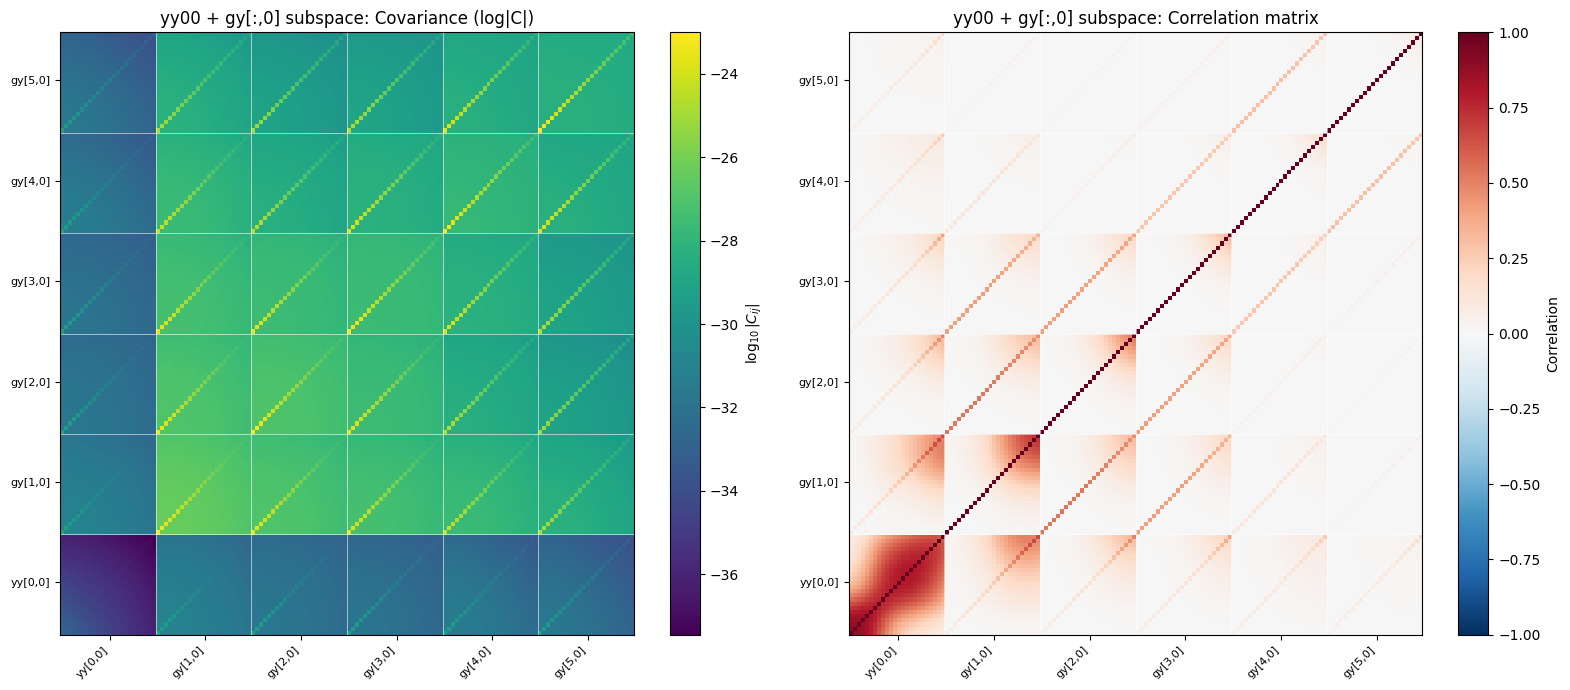

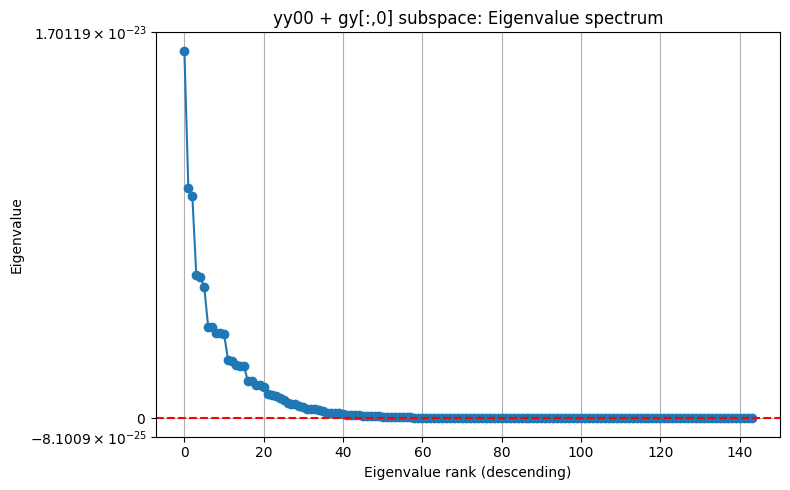

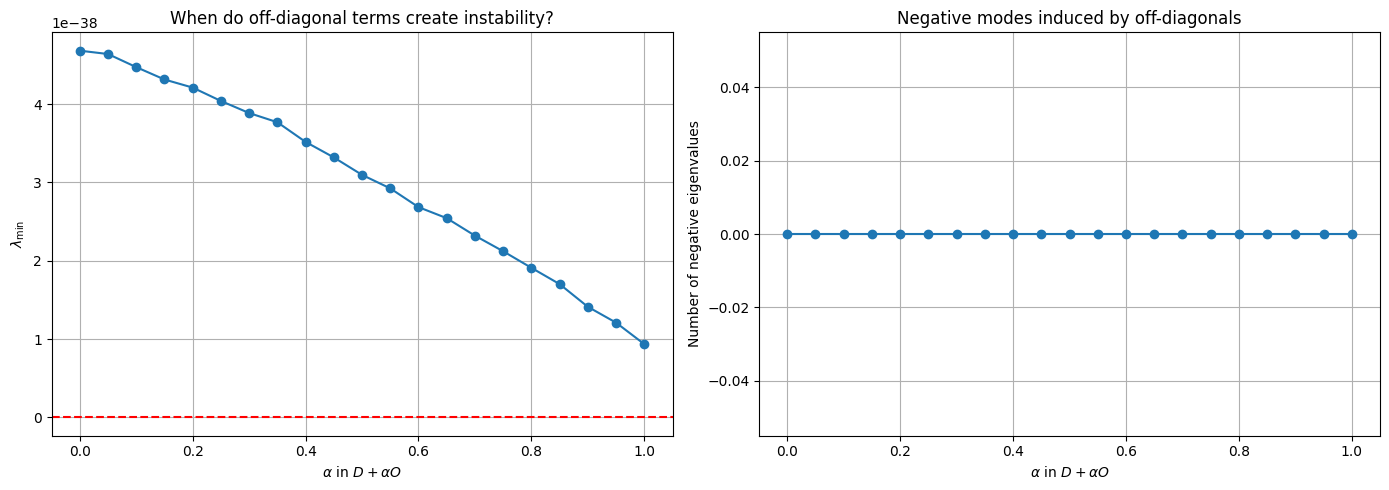

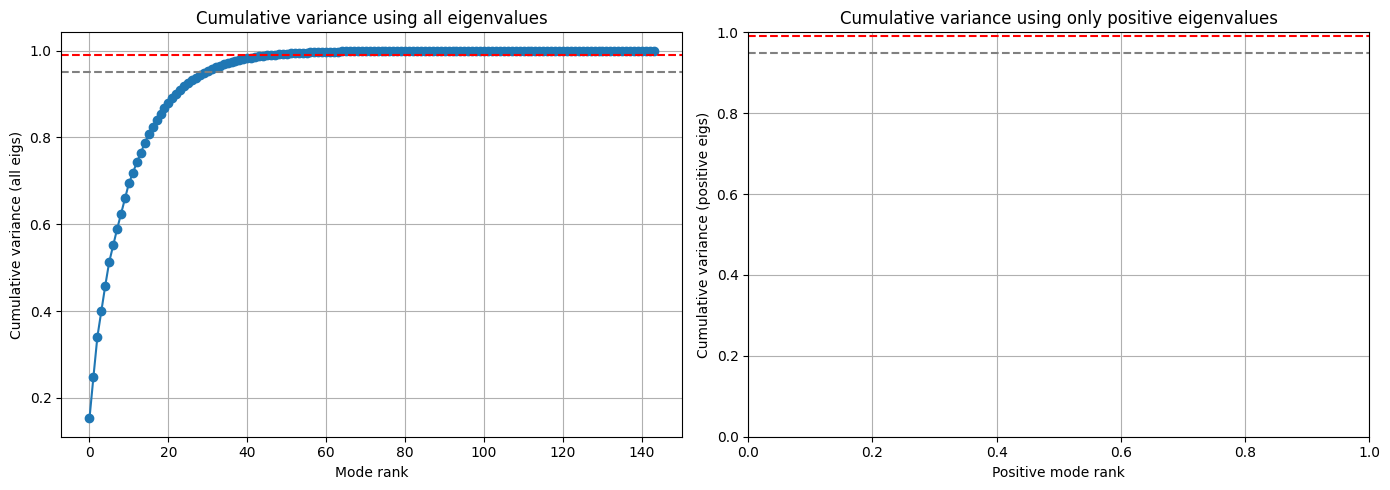

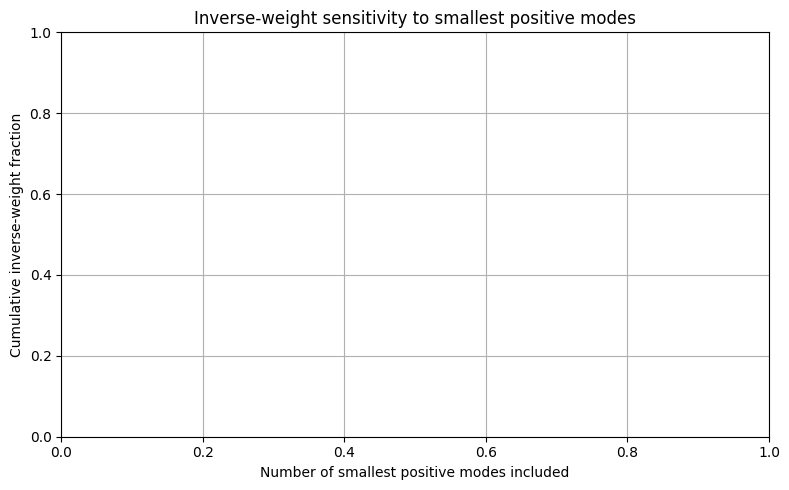

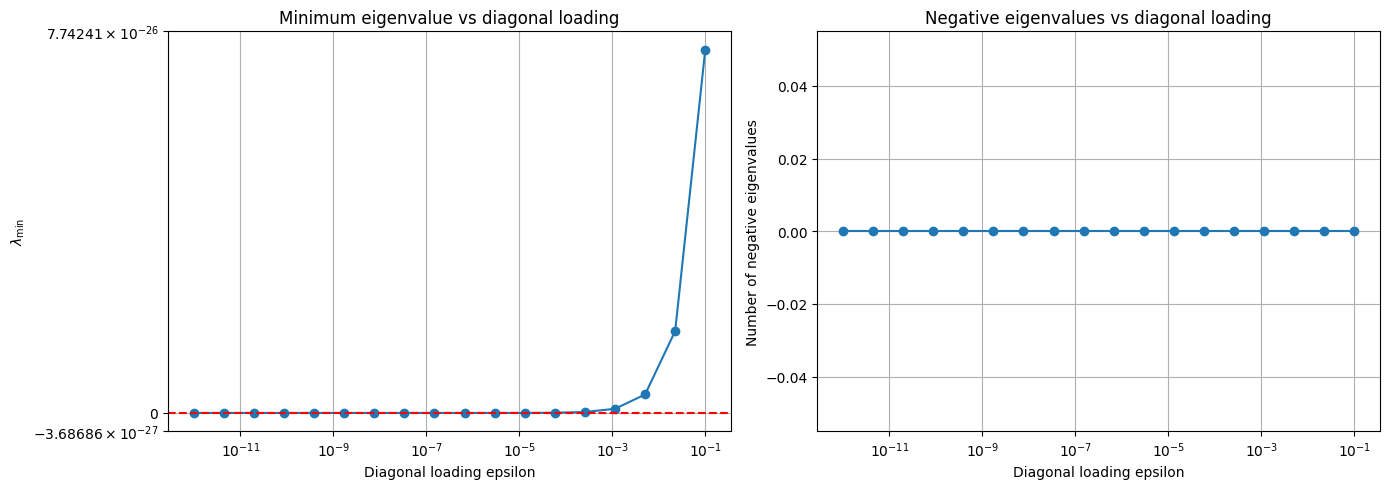

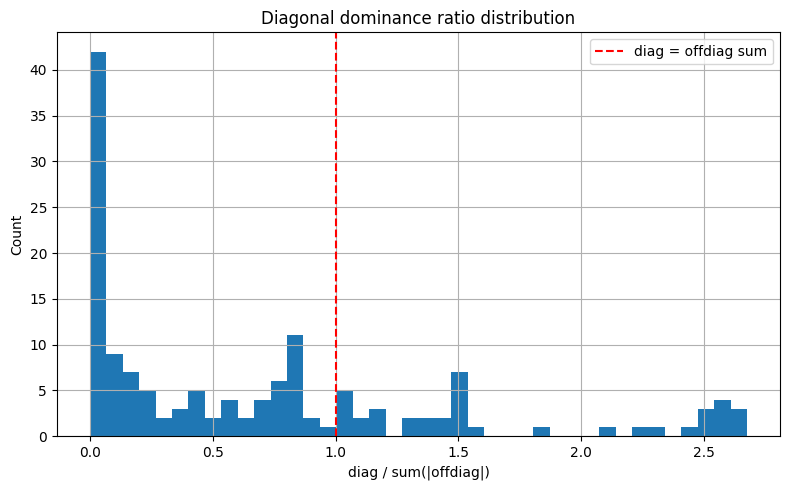

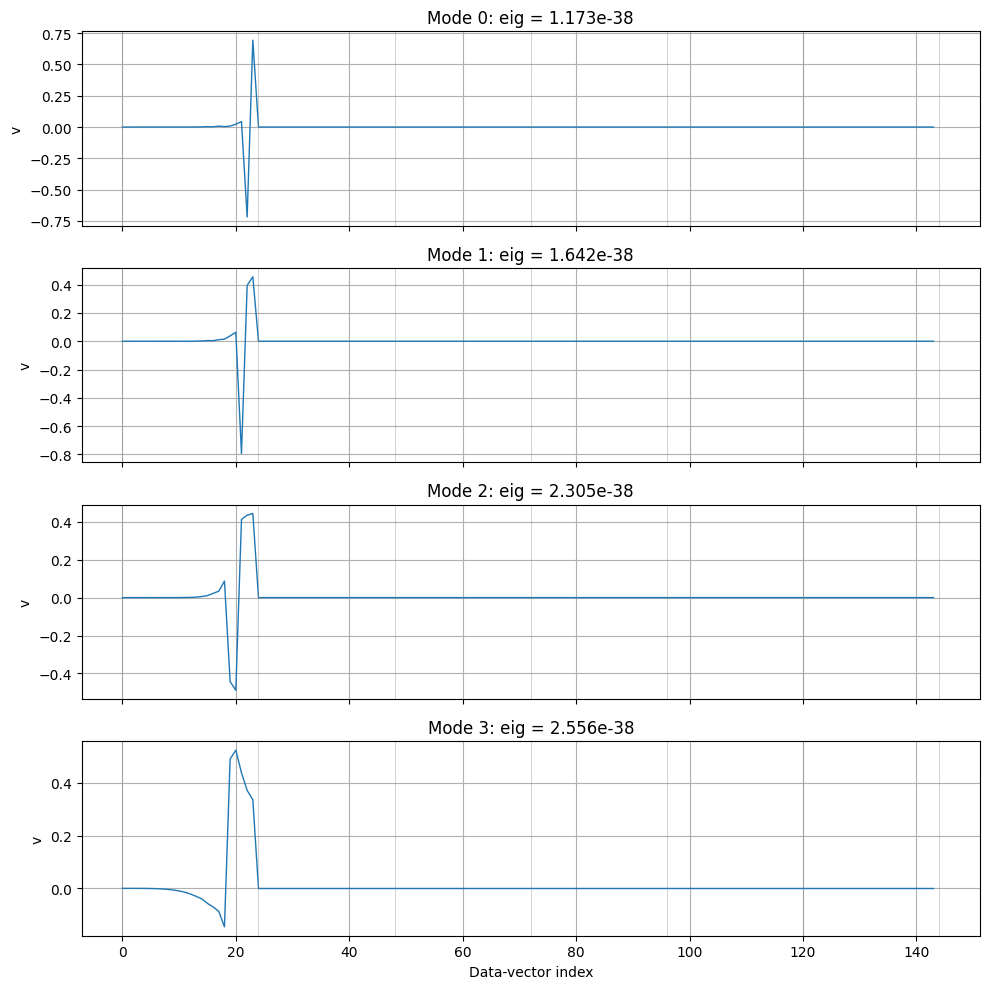

[{'mode_rank': 0,
  'eigval': np.float64(1.1725106547411198e-38),
  'block_fraction': array([1.00000000e+00, 2.14448172e-11, 3.76932004e-12, 1.73385417e-12,
         1.67484913e-12, 2.43990743e-12]),
  'top_blocks': [('yy[0,0]', np.float64(0.9999999999689373)),
   ('gy[1,0]', np.float64(2.1444817185487108e-11)),
   ('gy[2,0]', np.float64(3.769320037250258e-12)),
   ('gy[5,0]', np.float64(2.4399074276412588e-12)),
   ('gy[3,0]', np.float64(1.7338541731661532e-12))]},
 {'mode_rank': 1,
  'eigval': np.float64(1.641540135978215e-38),
  'block_fraction': array([1.00000000e+00, 1.87974049e-11, 2.94852299e-12, 1.33033583e-12,
         1.38619848e-12, 1.99438588e-12]),
  'top_blocks': [('yy[0,0]', np.float64(0.9999999999735432)),
   ('gy[1,0]', np.float64(1.8797404851922977e-11)),
   ('gy[2,0]', np.float64(2.9485229902647593e-12)),
   ('gy[5,0]', np.float64(1.994385880185117e-12)),
   ('gy[4,0]', np.float64(1.386198481026641e-12))]},
 {'mode_rank': 2,
  'eigval': np.float64(2.3046131297551386e

In [57]:


def build_selected_covariance(cov_test, ell_th, selected_blocks):
    """
    Build covariance matrix for a chosen list of (probe, [b1,b2]) blocks.

    Parameters
    ----------
    cov_test : object
        Must contain covtot_dict.
    ell_th : array
        Multipole array.
    selected_blocks : list of tuples
        Example:
        [('yy', [0,0]), ('gy', [1,0]), ('gy', [2,0])]

    Returns
    -------
    cov_mat : (N,N) array
    tick_labels : list[str]
    """
    nell = len(ell_th)
    nblocks = len(selected_blocks)
    cov_mat = np.zeros((nell * nblocks, nell * nblocks))

    for i, (probe1, (b1, b2)) in enumerate(selected_blocks):
        for j, (probe2, (b3, b4)) in enumerate(selected_blocks):
            sl1 = slice(i * nell, (i + 1) * nell)
            sl2 = slice(j * nell, (j + 1) * nell)

            key_fwd = f"{probe1}_{probe2}"
            key_rev = f"{probe2}_{probe1}"
            bin_fwd = f"bin_{b1}_{b2}_{b3}_{b4}"
            bin_rev = f"bin_{b3}_{b4}_{b1}_{b2}"

            if key_fwd in cov_test.covtot_dict and bin_fwd in cov_test.covtot_dict[key_fwd]:
                cov_mat[sl1, sl2] = cov_test.covtot_dict[key_fwd][bin_fwd]
            elif key_rev in cov_test.covtot_dict and bin_rev in cov_test.covtot_dict[key_rev]:
                cov_mat[sl1, sl2] = cov_test.covtot_dict[key_rev][bin_rev]
            else:
                raise KeyError(f"Missing block: {key_fwd}/{bin_fwd} and {key_rev}/{bin_rev}")

    tick_labels = [f"{p}[{b[0]},{b[1]}]" for p, b in selected_blocks]
    return cov_mat, tick_labels

selected_blocks = [
    ('yy', [0, 0]),
    ('gy', [1, 0]),
    ('gy', [2, 0]),
    ('gy', [3, 0]),
    ('gy', [4, 0]),
    ('gy', [5, 0]),
]

cov_sub, tick_labels_sub = build_selected_covariance(cov_test, ell_th, selected_blocks)

nell_sub = len(ell_th)

diag_results_sub = covariance_diagnostic_suite(
    C=cov_sub,
    d=None,
    name="yy00 + gy[:,0] subspace",
    tick_labels=tick_labels_sub,
    nell=nell_sub,
    figdir=FIGDIR,
    save_tag="yy00_gy0_subspace",
    n_modes_report=5,
)

diag_results_sub["stats_raw"]["lambda_min"]
diag_results_sub["diag_offdiag"]["first_neg_alpha"]
diag_results_sub["fro_rel_to_psd"]
diag_results_sub["mode_block_info"]

Using field: tot_ellsurvey
Available labels: ['yy[0,0]', 'gy[1,0]', 'gy[2,0]', 'gy[3,0]', 'gy[4,0]', 'gy[5,0]']


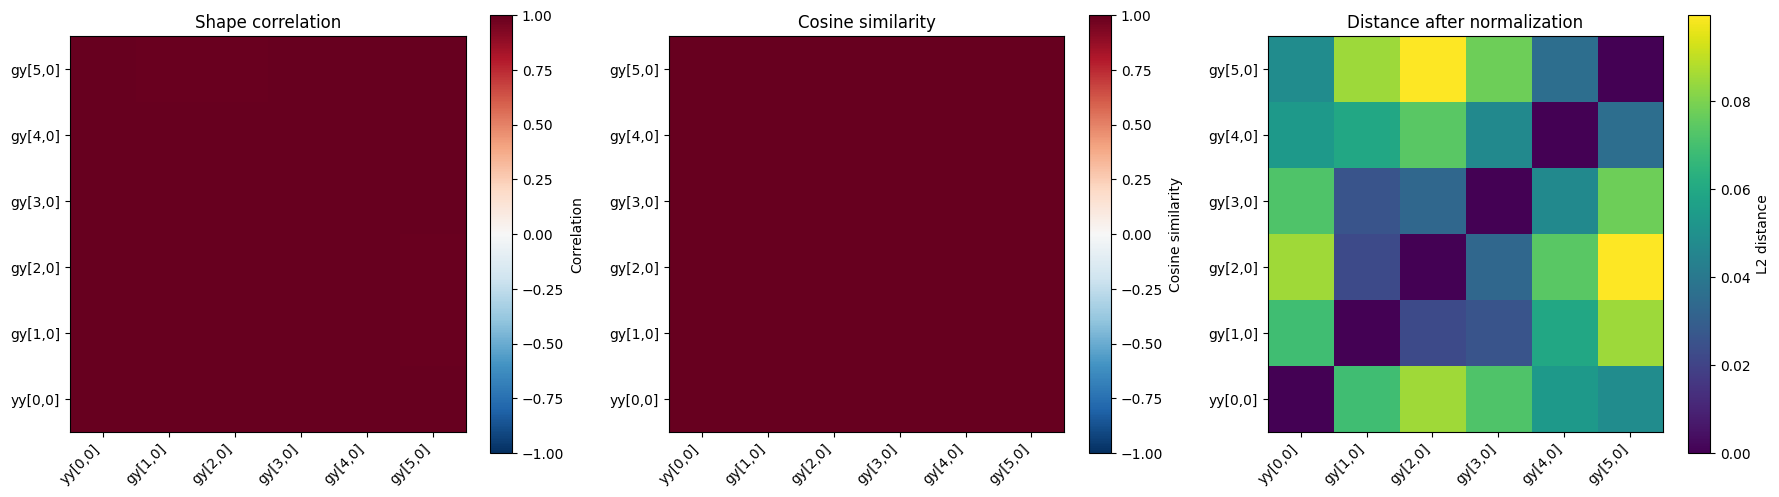

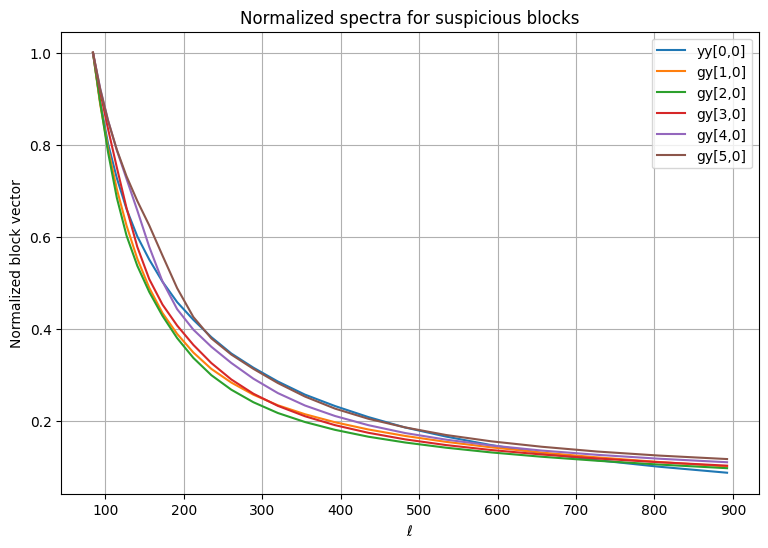

In [60]:
def extract_cl_vectors(cov_test, selected_blocks, field_name=None):
    """
    Extract the ell-dependent vectors for selected (probe, [b1,b2]) blocks.

    field_name:
        If None, tries one of:
        'tot_ellsurvey', 'tot_plus_noise_ellsurvey', 'cl', 'ellsurvey'
    """
    out = {}
    candidates = ['tot_ellsurvey', 'tot_plus_noise_ellsurvey', 'cl', 'ellsurvey']

    for probe, (b1, b2) in selected_blocks:
        block_key = f"bin_{b1}_{b2}"
        block = cov_test.Cl_result_dict[probe][block_key]

        fname = field_name
        if fname is None:
            found = None
            for cand in candidates:
                if cand in block:
                    found = cand
                    break
            if found is None:
                raise KeyError(f"No known field found in Cl_result_dict[{probe}][{block_key}]")
            fname = found

        out[f"{probe}[{b1},{b2}]"] = np.asarray(block[fname]).ravel()

    return out, fname

cl_vectors, used_field = extract_cl_vectors(cov_test, selected_blocks, field_name=None)
print("Using field:", used_field)
print("Available labels:", list(cl_vectors.keys()))

def compare_block_shapes(cl_vectors, make_plots=True):
    """
    Compare shape similarity between ell-dependent vectors.
    Returns:
      - correlation matrix
      - cosine similarity matrix
      - L2 distance matrix after normalization
    """
    labels = list(cl_vectors.keys())
    X = np.array([cl_vectors[k] for k in labels], dtype=float)

    # mean/std normalized for Pearson-like comparison
    Xc = X - X.mean(axis=1, keepdims=True)
    Xstd = Xc / np.where(Xc.std(axis=1, keepdims=True) > 0, Xc.std(axis=1, keepdims=True), 1.0)
    corr = np.corrcoef(Xstd)

    # unit-norm cosine similarity
    Xn = X / np.where(np.linalg.norm(X, axis=1, keepdims=True) > 0,
                      np.linalg.norm(X, axis=1, keepdims=True), 1.0)
    cosine = Xn @ Xn.T

    # L2 distance after unit normalization
    diff = Xn[:, None, :] - Xn[None, :, :]
    l2dist = np.sqrt(np.sum(diff**2, axis=-1))

    if make_plots:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im0 = axes[0].imshow(corr, origin='lower', vmin=-1, vmax=1, cmap='RdBu_r')
        plt.colorbar(im0, ax=axes[0], label='Correlation')
        axes[0].set_title('Shape correlation')

        im1 = axes[1].imshow(cosine, origin='lower', vmin=-1, vmax=1, cmap='RdBu_r')
        plt.colorbar(im1, ax=axes[1], label='Cosine similarity')
        axes[1].set_title('Cosine similarity')

        im2 = axes[2].imshow(l2dist, origin='lower', cmap='viridis')
        plt.colorbar(im2, ax=axes[2], label='L2 distance')
        axes[2].set_title('Distance after normalization')

        for ax in axes:
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha='right')
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels)

        plt.tight_layout()
        plt.show()

    return {
        "labels": labels,
        "corr": corr,
        "cosine": cosine,
        "l2dist": l2dist,
    }

shape_comp = compare_block_shapes(cl_vectors, make_plots=True)

plt.figure(figsize=(9, 6))
for label, vec in cl_vectors.items():
    vecn = vec / np.max(np.abs(vec))
    plt.plot(ell_th, vecn, label=label)

plt.xlabel(r'$\ell$')
plt.ylabel('Normalized block vector')
plt.title('Normalized spectra for suspicious blocks')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGDIR, "block_vector_comparison.png"))
plt.show()


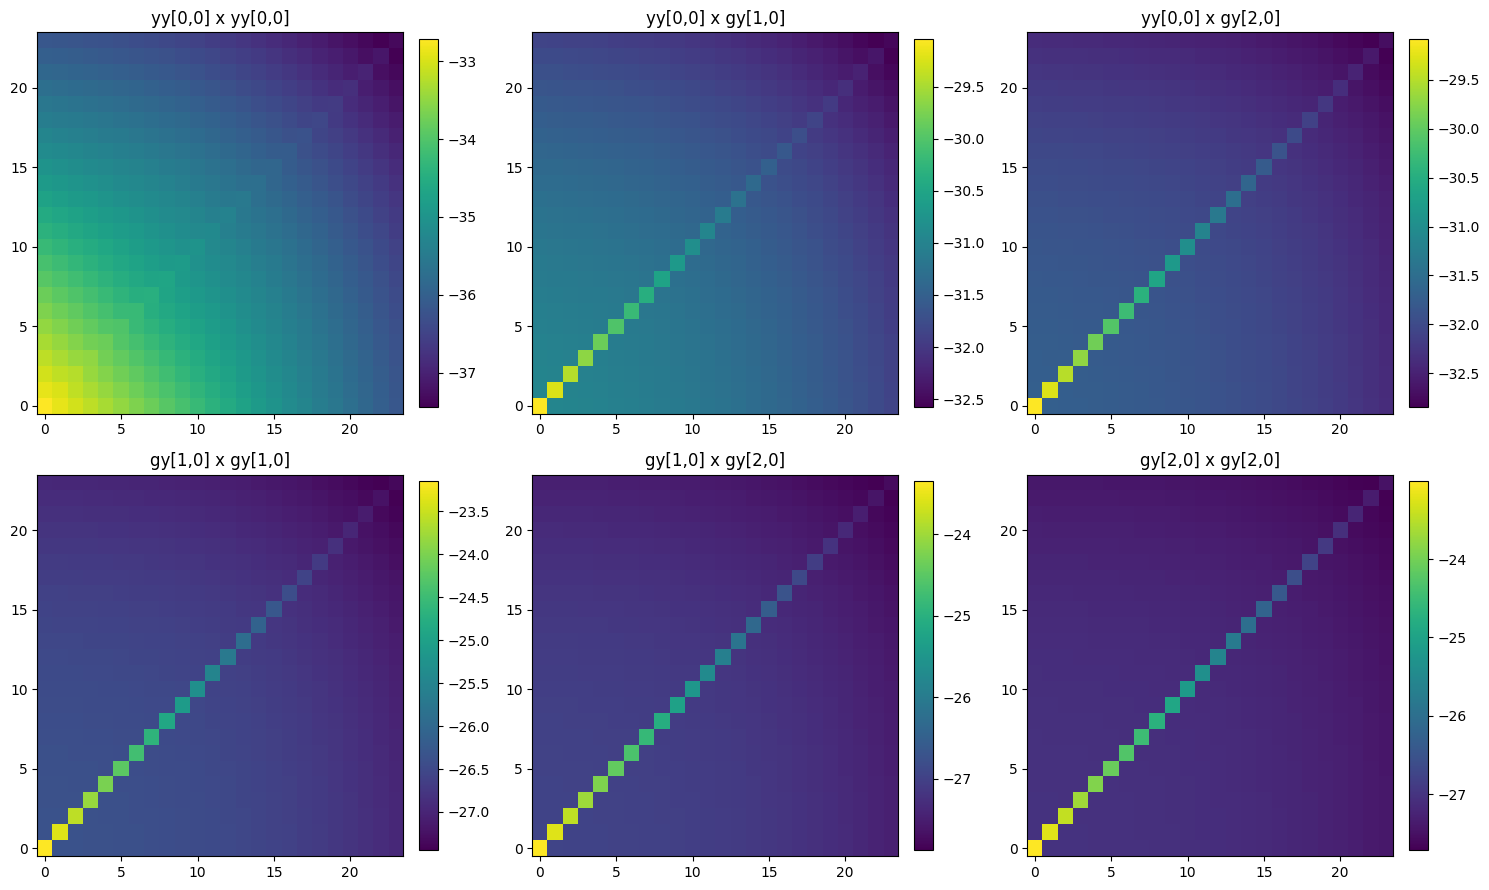

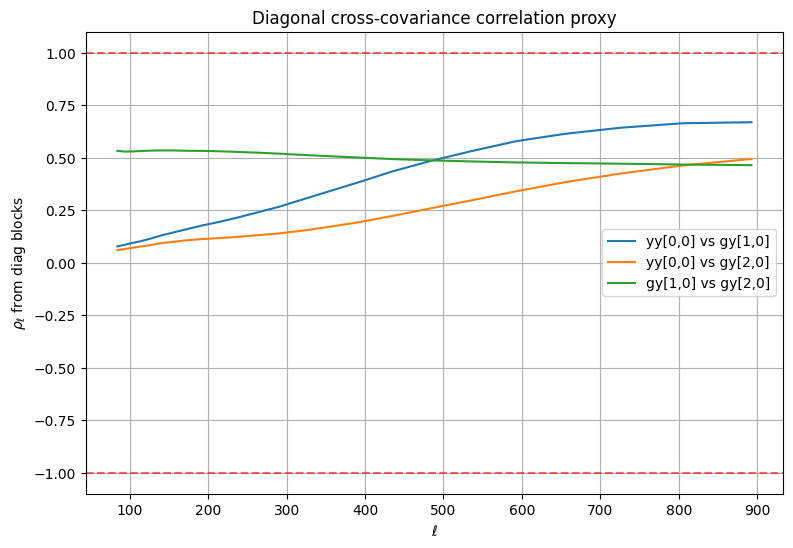


--- yy[0,0] x yy[0,0] ---
shape          : (24, 24)
min            : 3.562e-38
max            : 1.946e-33
fro norm       : 3.848e-33
lambda_min     : 2.013e-38
lambda_max     : 3.842e-33

--- yy[0,0] x gy[1,0] ---
shape          : (24, 24)
min            : 2.635e-33
max            : 9.123e-30
fro norm       : 1.183e-29
lambda_min     : 8.753e-34
lambda_max     : 9.140e-30

--- yy[0,0] x gy[2,0] ---
shape          : (24, 24)
min            : 1.415e-33
max            : 8.318e-30
fro norm       : 1.069e-29
lambda_min     : 7.887e-34
lambda_max     : 8.319e-30

--- gy[1,0] x gy[1,0] ---
shape          : (24, 24)
min            : 3.623e-28
max            : 7.104e-24
fro norm       : 8.944e-24
lambda_min     : 1.365e-28
lambda_max     : 7.104e-24

--- gy[1,0] x gy[2,0] ---
shape          : (24, 24)
min            : 1.340e-28
max            : 4.445e-24
fro norm       : 5.595e-24
lambda_min     : 6.837e-29
lambda_max     : 4.445e-24

--- gy[2,0] x gy[2,0] ---
shape          : (24, 24)
min    

In [61]:
def get_cov_block(cov_test, probe1, b1, b2, probe2, b3, b4):
    key_fwd = f"{probe1}_{probe2}"
    key_rev = f"{probe2}_{probe1}"
    bin_fwd = f"bin_{b1}_{b2}_{b3}_{b4}"
    bin_rev = f"bin_{b3}_{b4}_{b1}_{b2}"

    if key_fwd in cov_test.covtot_dict and bin_fwd in cov_test.covtot_dict[key_fwd]:
        return np.asarray(cov_test.covtot_dict[key_fwd][bin_fwd])
    elif key_rev in cov_test.covtot_dict and bin_rev in cov_test.covtot_dict[key_rev]:
        return np.asarray(cov_test.covtot_dict[key_rev][bin_rev]).T
    else:
        raise KeyError(f"Missing covariance block for {probe1}[{b1},{b2}] x {probe2}[{b3},{b4}]")
    
blocks_to_plot = [
    ('yy', 0, 0, 'yy', 0, 0),
    ('yy', 0, 0, 'gy', 1, 0),
    ('yy', 0, 0, 'gy', 2, 0),
    ('gy', 1, 0, 'gy', 1, 0),
    ('gy', 1, 0, 'gy', 2, 0),
    ('gy', 2, 0, 'gy', 2, 0),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (p1, a1, a2, p2, b1, b2) in zip(axes, blocks_to_plot):
    block = get_cov_block(cov_test, p1, a1, a2, p2, b1, b2)
    im = ax.imshow(np.log10(np.abs(block) + 1e-40), origin='lower', aspect='auto', cmap='viridis')
    ax.set_title(f'{p1}[{a1},{a2}] x {p2}[{b1},{b2}]')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


def diag_cross_correlation_from_blocks(C11, C22, C12):
    d11 = np.diag(C11)
    d22 = np.diag(C22)
    d12 = np.diag(C12)

    denom = np.sqrt(np.where(d11 > 0, d11, np.nan) * np.where(d22 > 0, d22, np.nan))
    rho = d12 / denom
    return rho

pairs = [
    (('yy',0,0), ('gy',1,0)),
    (('yy',0,0), ('gy',2,0)),
    (('gy',1,0), ('gy',2,0)),
]

plt.figure(figsize=(9,6))

for (p1,b1a,b1b), (p2,b2a,b2b) in pairs:
    C11 = get_cov_block(cov_test, p1, b1a, b1b, p1, b1a, b1b)
    C22 = get_cov_block(cov_test, p2, b2a, b2b, p2, b2a, b2b)
    C12 = get_cov_block(cov_test, p1, b1a, b1b, p2, b2a, b2b)

    rho = diag_cross_correlation_from_blocks(C11, C22, C12)
    plt.plot(ell_th, rho, label=f'{p1}[{b1a},{b1b}] vs {p2}[{b2a},{b2b}]')

plt.axhline(1, color='red', ls='--', alpha=0.6)
plt.axhline(-1, color='red', ls='--', alpha=0.6)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\rho_\ell$ from diag blocks')
plt.title('Diagonal cross-covariance correlation proxy')
plt.legend()
plt.grid(True)
plt.show()

def block_summary(block, label):
    evals = np.linalg.eigvalsh(0.5 * (block + block.T)) if block.shape[0] == block.shape[1] else None
    print(f"\n--- {label} ---")
    print(f"shape          : {block.shape}")
    print(f"min            : {np.min(block):.3e}")
    print(f"max            : {np.max(block):.3e}")
    print(f"fro norm       : {np.linalg.norm(block, ord='fro'):.3e}")
    if evals is not None:
        print(f"lambda_min     : {np.min(evals):.3e}")
        print(f"lambda_max     : {np.max(evals):.3e}")

for p1, a1, a2, p2, b1, b2 in blocks_to_plot:
    block = get_cov_block(cov_test, p1, a1, a2, p2, b1, b2)
    block_summary(block, f'{p1}[{a1},{a2}] x {p2}[{b1},{b2}]')